In [1]:
from IPython.display import Javascript, HTML, display

display(HTML("""
<style>
body,.jp-Notebook{font-family:'Segoe UI',Arial,sans-serif;background:#f7f9fc}
h1{color:#1a1a2e;font-size:2.4em;border-bottom:4px solid #6a0572;padding-bottom:10px}
h2{color:#16213e;font-size:1.8em;margin-top:40px;padding-left:12px;border-left:5px solid #6a0572}
h3{color:#0f3460;font-size:1.3em;margin-top:24px}
p,li{font-size:1.07em;line-height:1.75;color:#2d2d2d}
.callout{background:#f3e5f5;border-left:5px solid #6a0572;padding:14px 18px;border-radius:6px;margin:18px 0}
.warning{background:#fff8e1;border-left:5px solid #f9a825;padding:14px 18px;border-radius:6px;margin:18px 0}
.success{background:#e8f5e9;border-left:5px solid #43a047;padding:14px 18px;border-radius:6px;margin:18px 0}
.insight{background:#fce4ec;border-left:5px solid #c62828;padding:14px 18px;border-radius:6px;margin:18px 0}
table{border-collapse:collapse;width:100%;margin:16px 0}
th{background:#6a0572;color:white;padding:10px 14px;text-align:left}
td{padding:8px 14px;border-bottom:1px solid #dde}
tr:nth-child(even){background:#f9f0fa}
code{background:#f3e5f5;padding:2px 6px;border-radius:4px;font-size:0.93em}
</style>
"""))

display(Javascript("""
(function() {
    var old = document.getElementById('ts-toggle-btn');
    if (old) old.remove();
    var btn = document.createElement('button');
    btn.id  = 'ts-toggle-btn';
    btn.textContent = 'Show Code';
    btn.style.cssText = [
        'position:fixed','top:70px','right:20px','z-index:99999',
        'background:#6a0572','color:white','border:none','border-radius:8px',
        'padding:10px 20px','font-size:14px','cursor:pointer',
        'box-shadow:0 4px 14px rgba(106,5,114,0.4)','font-family:sans-serif',
        'transition:background 0.2s'
    ].join(';');
    btn.onmouseover = function(){ btn.style.background='#4a0350'; };
    btn.onmouseout  = function(){ btn.style.background='#6a0572'; };
    var visible = false;
    function getCells() {
        var lab     = Array.from(document.querySelectorAll('.jp-CodeCell .jp-Cell-inputWrapper'));
        var classic = Array.from(document.querySelectorAll('.code_cell .input'));
        return lab.length ? lab : classic;
    }
    btn.onclick = function() {
        visible = !visible;
        getCells().forEach(function(c){ c.style.display = visible ? '' : 'none'; });
        btn.textContent = visible ? 'Hide Code' : 'Show Code';
    };
    document.body.appendChild(btn);
    function hideOnReady() {
        var cells = getCells();
        if (cells.length > 0) { cells.forEach(function(c){ c.style.display='none'; }); }
        else { setTimeout(hideOnReady, 400); }
    }
    setTimeout(hideOnReady, 800);
})();
"""))


<IPython.core.display.Javascript object>

# Machine Learning Pipeline
## Time Series Analysis — Steam Indie Game Review Scores

<div class="callout">
<b>About this notebook</b><br>
A <b>presentation-ready notebook</b> for time series analysis of Steam indie game review quality,
covering the full ML pipeline from problem formulation to forecasting.<br>
Use the <b>Show / Hide Code</b> button (top-right) to toggle code cells.<br><br>
<b>Dataset:</b> Steam Indie Games (steam_indie_fresh.json) &mdash; 1,000 games, January 2020 – December 2024.<br>
<b>Target:</b> <code>wilson_mean</code> &mdash; monthly mean Wilson lower bound review score.<br>
<b>Research question:</b> Did the ChatGPT launch (November 2022) cause a structural break in indie game review scores?<br>
<b>Sections:</b> Problem Formulation &rarr; Data Collection &rarr; EDA &rarr; Feature Engineering &rarr; ARIMA Forecasting
</div>

---

In [2]:
# pip install --upgrade statsmodels --break-system-packages


import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import random

# ---- Colour palette and plot style ---------
PURPLE = "#6a0572"
VIOLET = "#c77dff"
ORANGE = "#f4a261"
RED    = "#e63946"
TEAL   = "#2d6a4f"
BLUE   = "#457b9d"
GOLD   = "#e9c46a"
PAL    = [PURPLE, ORANGE, TEAL, RED, BLUE, GOLD, VIOLET]

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#f7f9fc",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.labelsize":    12,
    "axes.titlesize":    14,
    "axes.titleweight":  "bold",
    "axes.titlecolor":   "#1a1a2e",
    "xtick.labelsize":   10,
    "ytick.labelsize":   10,
    "font.family":       "sans-serif",
    "axes.grid":         True,
    "grid.color":        "#dde",
    "grid.linewidth":    0.6,
    "legend.frameon":    False,
})
sns.set_palette(PAL)
print("Libraries loaded and plot style configured.")


Libraries loaded and plot style configured.


---
## Section 1 — Problem Formulation

| Question | Our Answer |
|---|---|
| **Why?** | The public release of ChatGPT (November 2022) raised concerns about AI-generated content lowering indie game quality — we want to quantify this effect |
| **Can we measure success?** | Yes — Wilson lower bound review score is a precise, continuous, and publicly available quality metric |
| **What kind of ML problem?** | **Time Series Forecasting** — track monthly average review scores over time and detect structural changes around the ChatGPT launch |

<div class="callout">
<b>Business Objective</b><br>
Given the <em>historical monthly average review scores</em> of Steam indie games,
detect whether a structural break occurred around the ChatGPT launch (November 2022)
and forecast future monthly average scores with a <b>MAPE ≤ 10%</b>.
</div>

### How time series differs from regression and classification

| Aspect | Regression / Classification | Time Series Forecasting |
|---|---|---|
| **Row order** | Rows are independent | Order is critical — past drives future |
| **Train/test split** | Random shuffle is fine | Must be chronological — never shuffle |
| **Target** | A column in the dataset | Future values of the series itself |
| **Key patterns** | Feature correlations | Trend, seasonality, cycles, noise |
| **Leakage risk** | Features from target | Using future data to predict the past |

### Forecast horizon and frequency

| Term | Our value | Meaning |
|---|---|---|
| **Frequency** | Monthly | One observation per month (release cohort) |
| **Forecast horizon** | 6 months | Predict the next 6 monthly average scores |
| **Lookback window** | 12 months | How much history the model uses |
| **Success metric** | MAPE ≤ 10% | Monthly forecasting is noisier than hourly — 10% is realistic |

---
## Section 2 — Data Collection

<div class="callout">
<b>Source:</b> Steam Indie Games dataset (steam_indie_fresh.json)<br>
<b>Frequency:</b> Monthly — 60 observations (January 2020 — December 2024)<br>
<b>Target:</b> Monthly mean Wilson lower bound review score<br>
<b>Games:</b> 1,000 indie games after reliability filter (≥ 10 reviews)<br>
<b>Features:</b> Aggregated from game-level data — all time series features engineered in Section 4
</div>

### Key checks specific to time series data

| Check | Why it matters |
|---|---|
| **No duplicate months** | Two rows for the same month would corrupt all lag calculations |
| **No missing months** | Gaps break the regular frequency assumption of most models |
| **Correct frequency** | All observations must be monthly — no mixed granularity |
| **Monotonically increasing** | Out-of-order months corrupt any window-based feature |
| **Sufficient games per month** | Months with very few games produce unreliable average scores |


### What to do when checks fail

| Issue | How to investigate | How to fix |
|---|---|---|
| **Duplicate months** | `df_monthly[df_monthly.index.duplicated(keep=False)]` — print the duplicated rows and compare game counts | Aggregate by mean: `df_monthly = df_monthly.groupby(level=0).mean()` |
| **Out-of-order months** | `df_monthly[df_monthly.index.to_series().diff().dt.days < 0]` — print the rows where time goes backward | Sort: `df_monthly = df_monthly.sort_index()`. Then re-run all checks |
| **Missing months (gaps)** | Already shown in Section 3.2 — the gap audit table shows start, end, and duration of each gap | Short gaps (1–2 months): interpolate with `interpolate(method='time', limit=2)`. Long gaps: flag with `was_missing` column and consider excluding from training |
| **Wilson score out of range** | `df_monthly[df_monthly["wilson_mean"] < 0]` or `> 1` — check which months and how many games | Wilson score is always 0–1 by definition. Out-of-range values indicate a data error — investigate the source games for that month |
| **Low-data months** | `df_monthly[df_monthly["game_count"] < 5]` — check which months have very few games | Flag these months with a `low_data` indicator. Consider weighting or excluding them from model training as their averages are statistically unreliable |
| **Missing values (NaN)** | Already shown in Section 3.2 — position strip and monthly bar chart | Same as missing months: short gaps interpolate, long gaps flag and exclude |

<div class="warning">
Always fix issues in this order: <b>sort → deduplicate → fill gaps → handle out-of-range scores</b>.
Fixing out-of-order months first is critical because deduplication and gap detection
both assume chronological order. Running them on unsorted data produces wrong results silently.
Note: unlike sensor data, Wilson scores cannot be negative or zero by construction —
so the final step is checking for low-data months rather than handling invalid sensor readings.
</div>

In [3]:
# ── Load raw data ─────────────────────────────────────────────────
import json, pandas as pd
import numpy as np

with open("steam_indie_fresh (1).json", "r", encoding="utf-8") as f:
    raw = json.load(f)
df_raw = pd.DataFrame(raw)

# ── Reliability filter ────────────────────────────────────────────
before = len(df_raw)
df_raw = df_raw[df_raw["review_total"] >= 10].copy()
print(f"Reliability filter: {before} → {len(df_raw)} games ({before - len(df_raw)} removed)")

# ── Key dates ─────────────────────────────────────────────────────
CHATGPT_DATE = pd.Timestamp("2022-11-01")
WINDOW_START = pd.Timestamp("2020-01-01")
WINDOW_END   = pd.Timestamp("2024-12-01")

# ── Build monthly time series ─────────────────────────────────────
df_monthly = (
    df_raw
    .groupby("release_year_month")
    .agg(
        wilson_mean         = ("review_wilson_lower",   "mean"),
        wilson_median       = ("review_wilson_lower",   "median"),
        positive_ratio_mean = ("review_positive_ratio", "mean"),
        game_count          = ("appid",                 "count"),
    )
    .reset_index()
)
df_monthly["release_year_month"] = pd.to_datetime(df_monthly["release_year_month"])
df_monthly = (df_monthly
    .sort_values("release_year_month")
    .set_index("release_year_month")
)
df_monthly = df_monthly.loc[WINDOW_START:WINDOW_END]  # Temporal range filter applied: WINDOW_START to WINDOW_END
df_monthly.index.freq = "MS"

ts = df_monthly["wilson_mean"].copy()

print(f"Shape         : {df_monthly.shape}")
print(f"Date range    : {ts.index.min().strftime('%b %Y')}  →  {ts.index.max().strftime('%b %Y')}")
print(f"Frequency     : {pd.infer_freq(ts.index)}")
print(f"Missing values: {ts.isna().sum()}")
print(f"Target range  : {ts.min():.4f} — {ts.max():.4f} (Wilson lower bound)")
print(f"Games/month   : min={df_monthly['game_count'].min()}, max={df_monthly['game_count'].max()}, mean={df_monthly['game_count'].mean():.1f}")
df_monthly.head()

Reliability filter: 1000 → 1000 games (0 removed)
Shape         : (60, 4)
Date range    : Jan 2020  →  Dec 2024
Frequency     : MS
Missing values: 0
Target range  : 0.6057 — 0.8662 (Wilson lower bound)
Games/month   : min=6, max=25, mean=12.8


,wilson_mean,wilson_median,positive_ratio_mean,game_count
release_year_month,,,,
2020-01-01,0.652900,0.6599,0.767829,7
2020-02-01,0.679900,0.6751,0.759015,13
2020-03-01,0.620947,0.6337,0.710360,15
2020-04-01,0.690408,0.7519,0.761923,13
2020-05-01,0.681782,0.6425,0.762245,11


In [4]:
# ── Time Series Integrity Checks ─────────────────────────────────────────────
from scipy import stats

checks = {
    "Duplicate months":           df_monthly.index.duplicated().sum(),
    "Out-of-order months":        (df_monthly.index.to_series().diff().dt.days < 0).sum(),
    "Missing months (gaps)":      pd.date_range(df_monthly.index.min(),
                                                df_monthly.index.max(),
                                                freq="MS").difference(df_monthly.index).shape[0],
    "Negative Wilson scores":     (ts < 0).sum(),
    "Wilson score > 1":           (ts > 1).sum(),
    "Missing values (NaN)":       ts.isna().sum(),
    "Low-data months (< 5 games)":(df_monthly["game_count"] < 5).sum(),
}

print(f"{'Check':<38} {'Count':>8}  {'Status':>8}")
print("-" * 60)
for check, val in checks.items():
    status = "✓ OK" if val == 0 else "⚠ CHECK"
    flag   = "  <-- investigate" if val > 0 else ""
    print(f"{check:<38} {val:>8}  {status:>8}{flag}")

Check                                     Count    Status
------------------------------------------------------------
Duplicate months                              0      ✓ OK
Out-of-order months                           0      ✓ OK
Missing months (gaps)                         0      ✓ OK
Negative Wilson scores                        0      ✓ OK
Wilson score > 1                              0      ✓ OK
Missing values (NaN)                          0      ✓ OK
Low-data months (< 5 games)                   0      ✓ OK


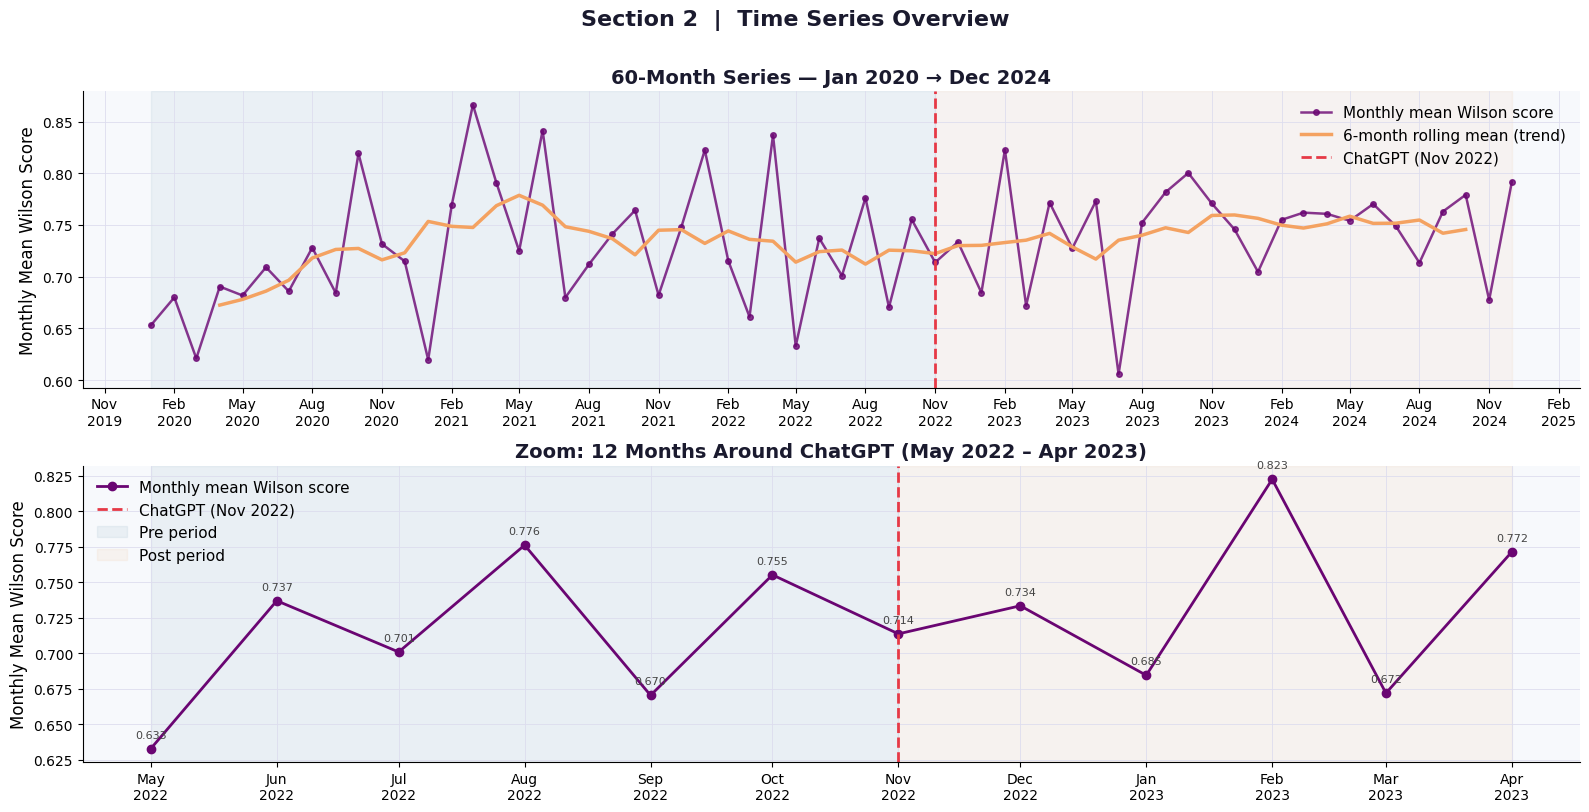

In [5]:
# ── Section 2 | Time Series Overview ─────────────────────────────────────────
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)
fig.suptitle("Section 2  |  Time Series Overview",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.01)

# ── Top: Full series (60 months) ──────────────────────────────────────────────
axes[0].plot(ts.index, ts.values,
             color=PURPLE, linewidth=1.8, alpha=0.8, marker="o",
             markersize=4, label="Monthly mean Wilson score")

# 6-month rolling average
roll = ts.rolling(6, center=True).mean()
axes[0].plot(roll.index, roll.values,
             color=ORANGE, linewidth=2.5, label="6-month rolling mean (trend)")

# ChatGPT break line
axes[0].axvline(CHATGPT_DATE, color=RED, linestyle="--",
                linewidth=2, label="ChatGPT (Nov 2022)")

# Pre / Post shading
axes[0].axvspan(ts.index.min(), CHATGPT_DATE,
                alpha=0.07, color=BLUE)
axes[0].axvspan(CHATGPT_DATE, ts.index.max(),
                alpha=0.07, color=ORANGE)

axes[0].set_title("60-Month Series — Jan 2020 → Dec 2024")
axes[0].set_ylabel("Monthly Mean Wilson Score")
axes[0].legend(fontsize=11)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

# ── Bottom: Zoom — 12 months around ChatGPT (6 before + 6 after) ─────────────
zoom_start = "2022-05-01"
zoom_end   = "2023-04-01"
zoom = ts[zoom_start:zoom_end]

axes[1].plot(zoom.index, zoom.values,
             color=PURPLE, linewidth=2, marker="o",
             markersize=6, label="Monthly mean Wilson score")

axes[1].axvline(CHATGPT_DATE, color=RED, linestyle="--",
                linewidth=2, label="ChatGPT (Nov 2022)")
axes[1].axvspan(zoom.index.min(), CHATGPT_DATE,
                alpha=0.08, color=BLUE, label="Pre period")
axes[1].axvspan(CHATGPT_DATE, zoom.index.max(),
                alpha=0.08, color=ORANGE, label="Post period")

# Value labels on each point
for date, val in zip(zoom.index, zoom.values):
    axes[1].annotate(f"{val:.3f}", (date, val),
                     textcoords="offset points", xytext=(0, 8),
                     fontsize=8, ha="center", color="#444")

axes[1].set_title("Zoom: 12 Months Around ChatGPT (May 2022 – Apr 2023)")
axes[1].set_ylabel("Monthly Mean Wilson Score")
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

---
## Section 3 — Evaluating Your Data (EDA)

<div class="callout">
<b>Goal:</b> Understand the structure of the monthly Wilson score series before modelling.<br>
Time series EDA has a different focus from cross-sectional EDA:<br>
&bull; <b>Trend</b> &mdash; did average review quality drift up or down over the 2020&ndash;2024 window?<br>
&bull; <b>Seasonality</b> &mdash; are there repeating patterns by month or quarter (e.g. games released in certain seasons score differently)?<br>
&bull; <b>Stationarity</b> &mdash; does the mean and variance stay constant over time, or shift around the ChatGPT launch?<br>
&bull; <b>Autocorrelation</b> &mdash; how much does last month's average score predict this month's, and at which lags?<br>
&bull; <b>Anomalies</b> &mdash; are there unusual months with abnormally high or low scores that need explanation?
</div>


### 3.1 &mdash; Target Distribution and Summary Statistics


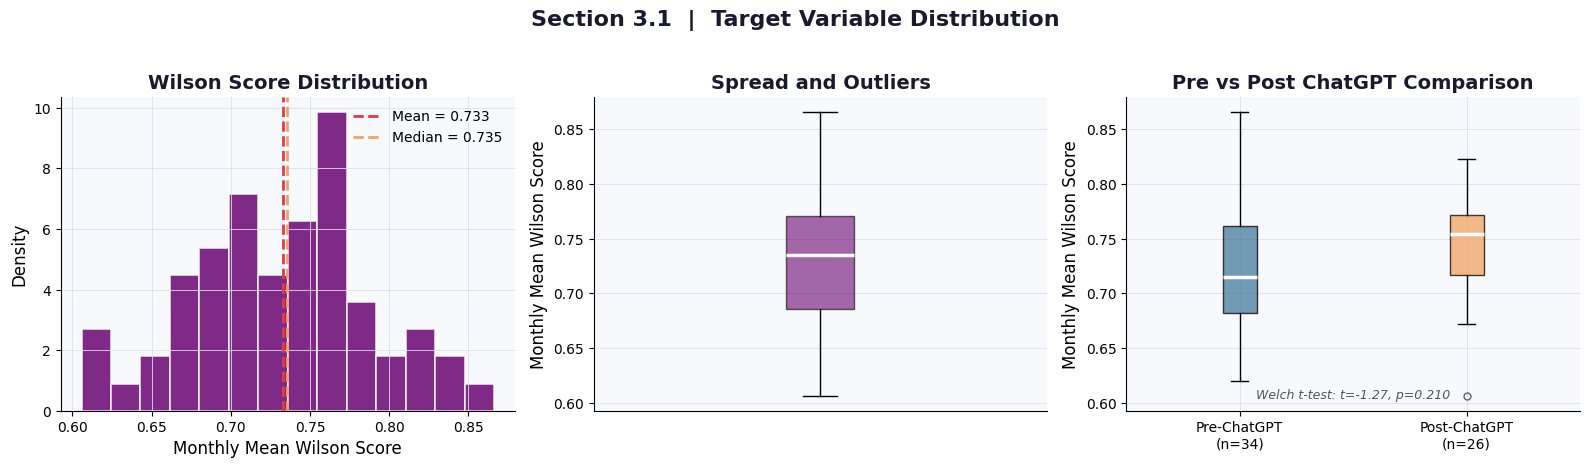

Mean      : 0.7330
Std. dev  : 0.0571
Skewness  : -0.028
Min / Max : 0.6057 / 0.8662

Pre  mean : 0.7249   std: 0.0634
Post mean : 0.7436   std: 0.0468
t=-1.268, p=0.2099 → no significant difference (p > 0.05)


In [6]:
# ── Section 3.1 | Target Variable Distribution ────────────────────────────────
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle("Section 3.1  |  Target Variable Distribution",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.03)

pre  = ts[ts.index <  CHATGPT_DATE]
post = ts[ts.index >= CHATGPT_DATE]

# ── Left: Histogram ───────────────────────────────────────────────────────────
axes[0].hist(ts, bins=14, color=PURPLE, edgecolor="white",
             linewidth=1.2, alpha=0.85, density=True)
axes[0].axvline(ts.mean(),   color=RED,    linestyle="--", linewidth=2,
                label=f"Mean = {ts.mean():.3f}")
axes[0].axvline(ts.median(), color=ORANGE, linestyle="--", linewidth=2,
                label=f"Median = {ts.median():.3f}")
axes[0].set_title("Wilson Score Distribution")
axes[0].set_xlabel("Monthly Mean Wilson Score")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=10)

# ── Middle: Box plot (full series) ────────────────────────────────────────────
axes[1].boxplot(ts, patch_artist=True,
                boxprops={"facecolor": PURPLE, "alpha": 0.6},
                medianprops={"color": "white", "linewidth": 2.5},
                flierprops={"marker": "o", "markerfacecolor": RED,
                            "markersize": 5, "alpha": 0.6})
axes[1].set_title("Spread and Outliers")
axes[1].set_ylabel("Monthly Mean Wilson Score")
axes[1].set_xticks([])

# ── Right: Pre vs Post box plot ───────────────────────────────────────────────
bp = axes[2].boxplot(
    [pre, post], patch_artist=True,
    labels=[f"Pre-ChatGPT\n(n={len(pre)})", f"Post-ChatGPT\n(n={len(post)})"],
    boxprops={"alpha": 0.75},
    medianprops={"color": "white", "linewidth": 2.5},
    flierprops={"marker": "o", "markersize": 5, "alpha": 0.6}
)
bp["boxes"][0].set_facecolor(BLUE)
bp["boxes"][1].set_facecolor(ORANGE)
axes[2].set_title("Pre vs Post ChatGPT Comparison")
axes[2].set_ylabel("Monthly Mean Wilson Score")

# t-test result
t_stat, t_p = stats.ttest_ind(pre, post)
axes[2].text(0.5, 0.04,
             f"Welch t-test: t={t_stat:.2f}, p={t_p:.3f}",
             transform=axes[2].transAxes, ha="center",
             fontsize=9, color="#555", style="italic")

plt.tight_layout()
plt.show()

print(f"Mean      : {ts.mean():.4f}")
print(f"Std. dev  : {ts.std():.4f}")
print(f"Skewness  : {ts.skew():.3f}")
print(f"Min / Max : {ts.min():.4f} / {ts.max():.4f}")
print(f"\nPre  mean : {pre.mean():.4f}   std: {pre.std():.4f}")
print(f"Post mean : {post.mean():.4f}   std: {post.std():.4f}")
print(f"t={t_stat:.3f}, p={t_p:.4f} → {'significant difference ✓' if t_p < 0.05 else 'no significant difference (p > 0.05)'}")

### 3.2 &mdash; Missing Values and Gap Analysis

<div class="warning">
In time series, missing values are more damaging than in cross-sectional data.
A gap in the middle of the series breaks continuity and makes all lag-based features
around that gap unreliable. You must decide: interpolate, forward-fill, or flag and exclude.
</div>


In [7]:
# ── Section 3.2 | Missing Value and Gap Analysis ──────────────────────────────
# We check for monthly gaps rather than hourly gaps.
# Integrity check already found 0 missing — this cell formalises that finding.

full_idx = pd.date_range(df_monthly.index.min(),
                         df_monthly.index.max(), freq="MS")
df_full  = df_monthly.reindex(full_idx)
df_full.index.name = "release_year_month"

# ── Missing value audit ───────────────────────────────────────────────────────
n_missing = df_full["wilson_mean"].isna().sum()
pct_miss  = n_missing / len(df_full) * 100

print("Total monthly slots : {:,}".format(len(df_full)))
print("Missing values      : {:,}  ({:.2f}%)".format(n_missing, pct_miss))
print("Window              : {}  →  {}".format(
    df_full.index.min().strftime("%b %Y"),
    df_full.index.max().strftime("%b %Y")))

# ── Consecutive gap analysis ──────────────────────────────────────────────────
is_null    = df_full["wilson_mean"].isna()
gap_starts = df_full.index[is_null & ~is_null.shift(1).fillna(False)]
gap_ends   = df_full.index[is_null & ~is_null.shift(-1).fillna(False)]

if len(gap_starts) > 0:
    print("\nGaps detected (longest 10):")
    print("  {:<15} {:<15} {:>8}".format("Start", "End", "Months"))
    print("  " + "-" * 40)
    gaps = sorted(zip(gap_starts, gap_ends),
                  key=lambda x: (x[1] - x[0]).days, reverse=True)
    for s, e in gaps[:10]:
        months = round((e - s).days / 30) + 1
        print("  {:<15} {:<15} {:>8}".format(
            s.strftime("%b %Y"), e.strftime("%b %Y"), months))
else:
    print("\n✓ No gaps detected — series is complete and continuous.")
    print("  No interpolation or forward-fill required.")
    print("  All lag-based features can be safely computed.")

# ── Data density check (low-game months) ─────────────────────────────────────
print("\nMonthly game count distribution:")
print("  Minimum : {} games".format(df_monthly["game_count"].min()))
print("  Maximum : {} games".format(df_monthly["game_count"].max()))
print("  Mean    : {:.1f} games".format(df_monthly["game_count"].mean()))
print("  Months with < 5 games: {}".format((df_monthly["game_count"] < 5).sum()))

Total monthly slots : 60
Missing values      : 0  (0.00%)
Window              : Jan 2020  →  Dec 2024

✓ No gaps detected — series is complete and continuous.
  No interpolation or forward-fill required.
  All lag-based features can be safely computed.

Monthly game count distribution:
  Minimum : 6 games
  Maximum : 25 games
  Mean    : 12.8 games
  Months with < 5 games: 0


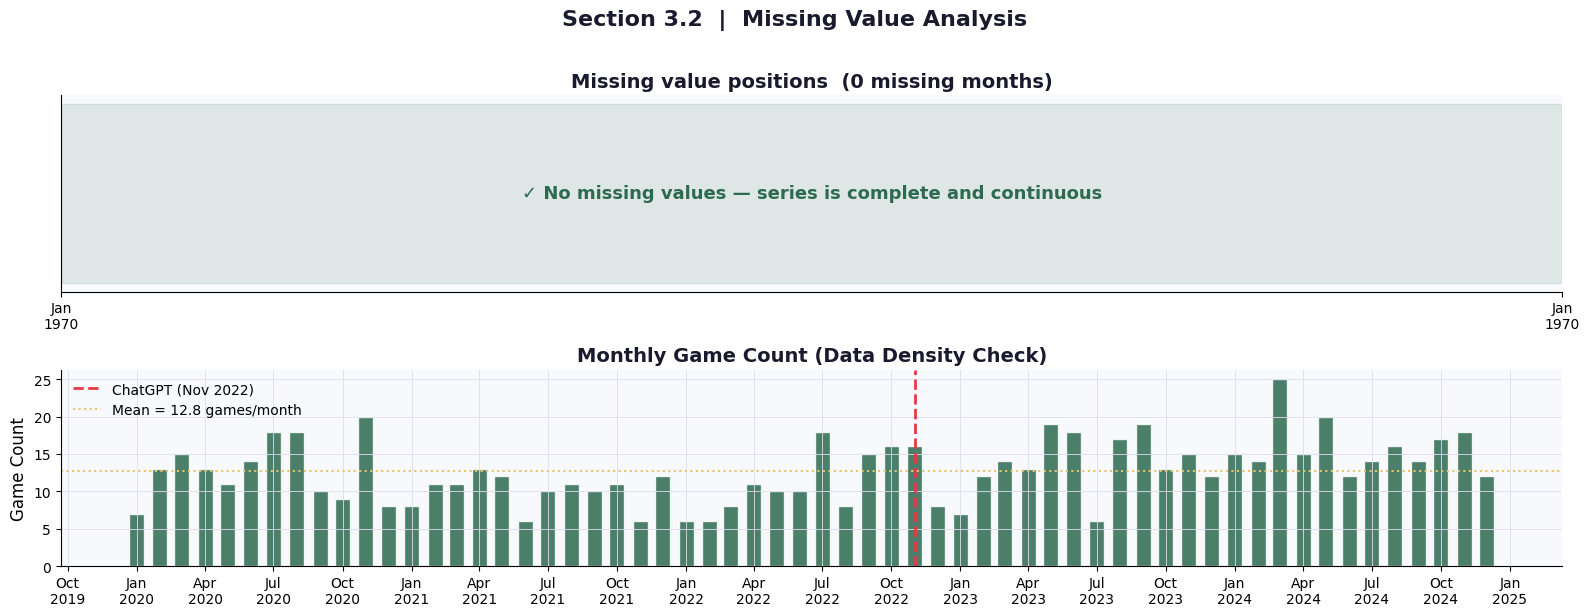

NaN after interpolation : 0 (already 0 missing — no change)
Months flagged as missing: 0

→ df is ready for downstream analysis.


In [8]:
# ── Section 3.2 | Missing Value Visualisation ─────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 6))
fig.suptitle("Section 3.2  |  Missing Value Analysis",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.02)

# ── Top: Missing value positions ──────────────────────────────────────────────
miss_months = df_full.index[df_full["wilson_mean"].isna()]
if len(miss_months) > 0:
    axes[0].scatter(miss_months, [1] * len(miss_months),
                    color=RED, s=80, alpha=0.8, marker="|")
else:
    axes[0].axhspan(0.5, 1.5, color=TEAL, alpha=0.12)
    axes[0].text(0.5, 0.5,
                 "✓ No missing values — series is complete and continuous",
                 ha="center", va="center", fontsize=13,
                 color=TEAL, fontweight="bold",
                 transform=axes[0].transAxes)

axes[0].set_title(f"Missing value positions  ({len(miss_months)} missing months)")
axes[0].set_ylabel("")
axes[0].set_yticks([])
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

# ── Bottom: Monthly game count (data density check) ───────────────────────────
axes[1].bar(df_monthly.index, df_monthly["game_count"],
            color=[RED if v < 5 else TEAL for v in df_monthly["game_count"]],
            width=20, edgecolor="white", alpha=0.85)
axes[1].axvline(CHATGPT_DATE, color=RED, linestyle="--",
                linewidth=2, label="ChatGPT (Nov 2022)")
axes[1].axhline(df_monthly["game_count"].mean(), color=GOLD,
                linestyle=":", linewidth=1.5,
                label=f"Mean = {df_monthly['game_count'].mean():.1f} games/month")
axes[1].set_title("Monthly Game Count (Data Density Check)")
axes[1].set_ylabel("Game Count")
axes[1].legend(fontsize=10)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.tight_layout()
plt.show()

# ── Prepare df for downstream analysis ───────────────────────────────────────
is_null           = df_full["wilson_mean"].isna()
df                = df_full.copy()
df["wilson_mean"] = df["wilson_mean"].interpolate(method="time")
df["was_missing"] = is_null.astype(int)

print(f"NaN after interpolation : {df['wilson_mean'].isna().sum()} "
      f"(already 0 missing — no change)")
print(f"Months flagged as missing: {df['was_missing'].sum()}")
print(f"\n→ df is ready for downstream analysis.")

### 3.3 &mdash; Seasonality Patterns

<div class="callout">
Time series often have <b>multiple layers of seasonality</b> stacked on top of each other.
Electricity consumption has three at once: hourly (within a day), daily (within a week),
and annual (within a year). Identifying all of them is essential before choosing a model.
</div>


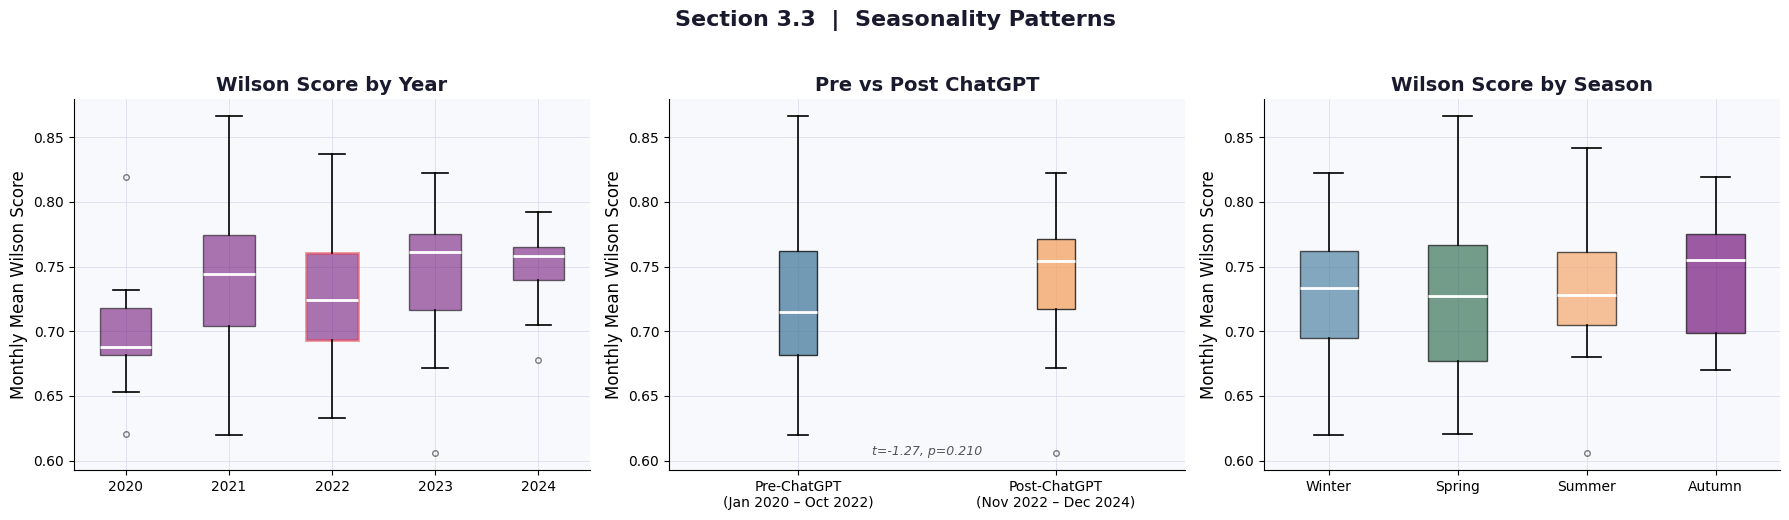

Season           Mean       Std     n
------------------------------------
Winter         0.7306    0.0582    15
Spring         0.7302    0.0714    15
Summer         0.7289    0.0539    15
Autumn         0.7423    0.0473    15


In [9]:
# ── Section 3.3 | Seasonality Patterns ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Section 3.3  |  Seasonality Patterns",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.03)

# ── Left: By year ─────────────────────────────────────────────────────────────
years     = sorted(df.index.year.unique())
year_data = [df["wilson_mean"][df.index.year == y].dropna() for y in years]
bp0 = axes[0].boxplot(year_data, patch_artist=True,
                boxprops={"facecolor": PURPLE, "alpha": 0.55},
                medianprops={"color": "white", "linewidth": 2},
                flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
                whiskerprops={"linewidth": 1.2},
                capprops={"linewidth": 1.2})
axes[0].set_xticklabels(years, fontsize=10)
axes[0].set_title("Wilson Score by Year")
axes[0].set_ylabel("Monthly Mean Wilson Score")
# Highlight ChatGPT year (2022)
chatgpt_idx = years.index(2022) + 1
bp0["boxes"][chatgpt_idx - 1].set_edgecolor(RED)
bp0["boxes"][chatgpt_idx - 1].set_linewidth(2)

# ── Middle: Pre vs Post ───────────────────────────────────────────────────────
pre  = ts[ts.index <  CHATGPT_DATE]
post = ts[ts.index >= CHATGPT_DATE]
bp1 = axes[1].boxplot(
    [pre, post], patch_artist=True,
    labels=[f"Pre-ChatGPT\n(Jan 2020 – Oct 2022)",
            f"Post-ChatGPT\n(Nov 2022 – Dec 2024)"],
    boxprops={"alpha": 0.75},
    medianprops={"color": "white", "linewidth": 2},
    flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
    whiskerprops={"linewidth": 1.2},
    capprops={"linewidth": 1.2})
bp1["boxes"][0].set_facecolor(BLUE)
bp1["boxes"][1].set_facecolor(ORANGE)
axes[1].set_title("Pre vs Post ChatGPT")
axes[1].set_ylabel("Monthly Mean Wilson Score")

from scipy import stats
t_stat, t_p = stats.ttest_ind(pre, post)
axes[1].text(0.5, 0.04, f"t={t_stat:.2f}, p={t_p:.3f}",
             transform=axes[1].transAxes, ha="center",
             fontsize=9, color="#555", style="italic")

# ── Right: By season ──────────────────────────────────────────────────────────
season_map = {12:"Winter",  1:"Winter",  2:"Winter",
               3:"Spring",  4:"Spring",  5:"Spring",
               6:"Summer",  7:"Summer",  8:"Summer",
               9:"Autumn", 10:"Autumn", 11:"Autumn"}
season_order  = ["Winter", "Spring", "Summer", "Autumn"]
season_colors = [BLUE, TEAL, ORANGE, PURPLE]

df["season"] = df.index.month.map(season_map)
season_data  = [df["wilson_mean"][df["season"] == s].dropna()
                for s in season_order]

bp2 = axes[2].boxplot(season_data, patch_artist=True,
                medianprops={"color": "white", "linewidth": 2},
                flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
                whiskerprops={"linewidth": 1.2},
                capprops={"linewidth": 1.2})
for patch, color in zip(bp2["boxes"], season_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.65)
axes[2].set_xticklabels(season_order, fontsize=10)
axes[2].set_title("Wilson Score by Season")
axes[2].set_ylabel("Monthly Mean Wilson Score")

plt.tight_layout()
plt.show()

# ── Seasonal averages ─────────────────────────────────────────────────────────
print(f"{'Season':<12} {'Mean':>8}  {'Std':>8}  {'n':>4}")
print("-" * 36)
for s in season_order:
    vals = df["wilson_mean"][df["season"] == s].dropna()
    print(f"{s:<12} {vals.mean():>8.4f}  {vals.std():>8.4f}  {len(vals):>4}")

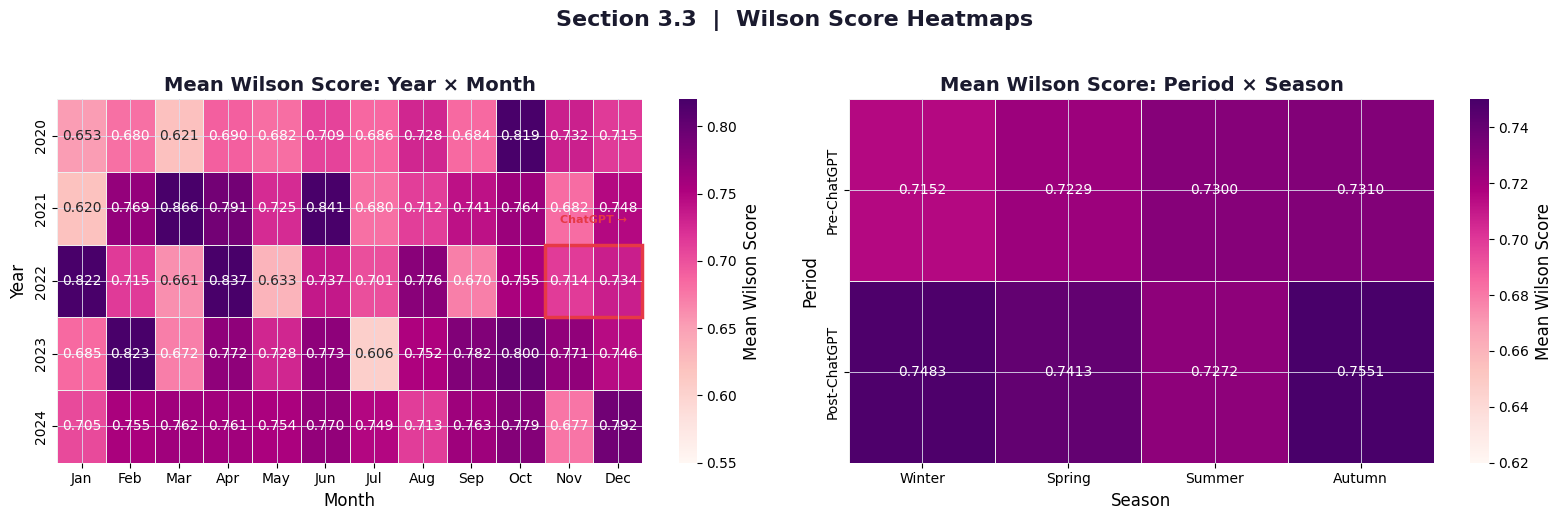

=== Year × Month Pivot ===
        Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec
year                                                                                    
2020  0.653  0.680  0.621  0.690  0.682  0.709  0.686  0.728  0.684  0.819  0.732  0.715
2021  0.620  0.769  0.866  0.791  0.725  0.841  0.680  0.712  0.741  0.764  0.682  0.748
2022  0.822  0.715  0.661  0.837  0.633  0.737  0.701  0.776  0.670  0.755  0.714  0.734
2023  0.685  0.823  0.672  0.772  0.728  0.773  0.606  0.752  0.782  0.800  0.771  0.746
2024  0.705  0.755  0.762  0.761  0.754  0.770  0.749  0.713  0.763  0.779  0.677  0.792

=== Period × Season Pivot ===
season        Winter  Spring  Summer  Autumn
period                                      
Pre-ChatGPT   0.7152  0.7229  0.7300  0.7310
Post-ChatGPT  0.7483  0.7413  0.7272  0.7551


In [10]:
# ── Section 3.3 | Wilson Score Heatmaps ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Section 3.3  |  Wilson Score Heatmaps",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.03)

# ── Left: Year × Month pivot ──────────────────────────────────────────────────
pivot_ym = df["wilson_mean"].copy().to_frame()
pivot_ym["year"]  = df.index.year
pivot_ym["month"] = df.index.month
pivot_ym = pivot_ym.pivot_table(
    values="wilson_mean", index="year", columns="month", aggfunc="mean"
)
pivot_ym.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]

sns.heatmap(pivot_ym, ax=axes[0], cmap="RdPu",
            cbar_kws={"label": "Mean Wilson Score"},
            annot=True, fmt=".3f", linewidths=0.5,
            linecolor="#eee", vmin=0.55, vmax=0.82)
axes[0].set_title("Mean Wilson Score: Year × Month")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Year")

# Mark ChatGPT break point (Nov 2022 = column 11, year 2022 = row index 2)
chatgpt_row = list(pivot_ym.index).index(2022)
axes[0].add_patch(plt.Rectangle((10, chatgpt_row), 2, 1,
                  fill=False, edgecolor=RED,
                  linewidth=2.5, clip_on=False))
axes[0].text(11, chatgpt_row - 0.3, "ChatGPT →", ha="center",
             fontsize=8, color=RED, fontweight="bold")

# ── Right: Period × Season pivot ──────────────────────────────────────────────
season_map = {12:"Winter",  1:"Winter",  2:"Winter",
               3:"Spring",  4:"Spring",  5:"Spring",
               6:"Summer",  7:"Summer",  8:"Summer",
               9:"Autumn", 10:"Autumn", 11:"Autumn"}
season_order = ["Winter", "Spring", "Summer", "Autumn"]

df["season"] = df.index.month.map(season_map)
df["period"] = df.index.map(
    lambda d: "Post-ChatGPT" if d >= CHATGPT_DATE else "Pre-ChatGPT"
)

pivot_ps = df.pivot_table(
    values="wilson_mean",
    index="period",
    columns="season",
    aggfunc="mean"
)[season_order]
pivot_ps = pivot_ps.loc[["Pre-ChatGPT", "Post-ChatGPT"]]

sns.heatmap(pivot_ps, ax=axes[1], cmap="RdPu",
            cbar_kws={"label": "Mean Wilson Score"},
            annot=True, fmt=".4f", linewidths=0.5,
            linecolor="#eee", vmin=0.62, vmax=0.75)
axes[1].set_title("Mean Wilson Score: Period × Season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Period")

plt.tight_layout()
plt.show()

# ── Print pivot tables ────────────────────────────────────────────────────────
print("=== Year × Month Pivot ===")
print(pivot_ym.round(3).to_string())
print("\n=== Period × Season Pivot ===")
print(pivot_ps.round(4).to_string())

### 3.4 &mdash; Time Series Decomposition

<div class="callout">
Decomposition splits the series into three components:<br>
&bull; <b>Trend</b> &mdash; the long-run direction (up, down, or flat)<br>
&bull; <b>Seasonal</b> &mdash; the repeating pattern at a fixed period<br>
&bull; <b>Residual</b> &mdash; what is left after removing trend and seasonality (should look like random noise)<br><br>
If the residual is <em>not</em> random &mdash; if it still shows patterns &mdash; the decomposition
missed something. That means there is an additional seasonality layer or a structural break.
</div>


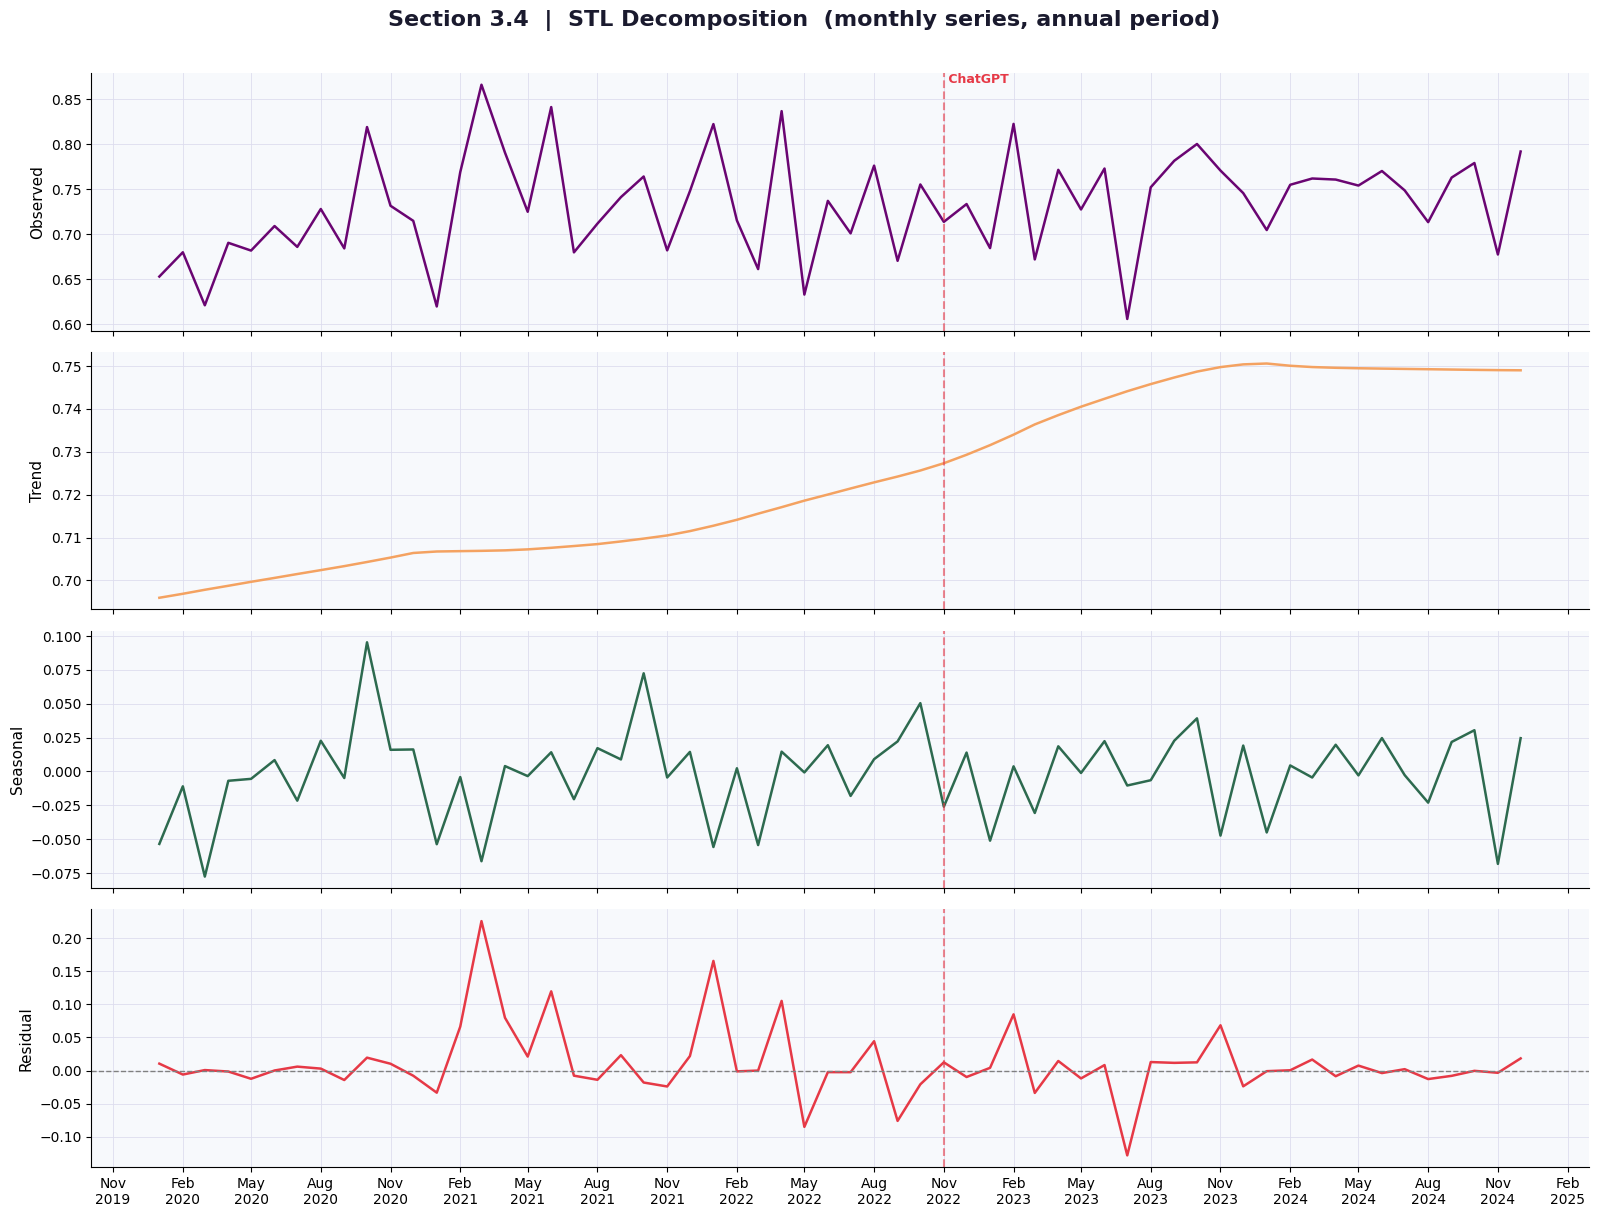

Trend strength    : 0.011  (0=none, 1=perfect)
Seasonal strength : 0.132  (0=none, 1=perfect)

Trend mean (pre)  : 0.7090
Trend mean (post) : 0.7446
Trend difference  : +0.0356  (↑ increase)


In [11]:
# ── Section 3.4 | STL Decomposition ──────────────────────────────────────────
from statsmodels.tsa.seasonal import STL

# period=12: annual seasonal cycle (12 months)
stl    = STL(ts, period=12, robust=True)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
fig.suptitle("Section 3.4  |  STL Decomposition  (monthly series, annual period)",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.01)

components = [
    (ts,              "Observed",   PURPLE),
    (result.trend,    "Trend",      ORANGE),
    (result.seasonal, "Seasonal",   TEAL),
    (result.resid,    "Residual",   RED),
]

for ax, (data, label, color) in zip(axes, components):
    ax.plot(data.index, data.values, color=color, linewidth=1.8)
    ax.set_ylabel(label, fontsize=11)
    if label == "Residual":
        ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.axvline(CHATGPT_DATE, color=RED, linestyle="--",
               linewidth=1.5, alpha=0.6)
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

# ChatGPT label on top panel only
axes[0].text(CHATGPT_DATE, axes[0].get_ylim()[1],
             " ChatGPT", color=RED, fontsize=9,
             va="top", fontweight="bold")

plt.tight_layout()
plt.show()

# ── Trend and seasonal strength ───────────────────────────────────────────────
strength_trend    = max(0, 1 - result.resid.var() /
                        (result.trend    + result.resid).var())
strength_seasonal = max(0, 1 - result.resid.var() /
                        (result.seasonal + result.resid).var())

print(f"Trend strength    : {strength_trend:.3f}  (0=none, 1=perfect)")
print(f"Seasonal strength : {strength_seasonal:.3f}  (0=none, 1=perfect)")
print()

# ── Trend direction: pre vs post ChatGPT ─────────────────────────────────────
trend_pre  = result.trend[result.trend.index <  CHATGPT_DATE].mean()
trend_post = result.trend[result.trend.index >= CHATGPT_DATE].mean()

print(f"Trend mean (pre)  : {trend_pre:.4f}")
print(f"Trend mean (post) : {trend_post:.4f}")
print(f"Trend difference  : {trend_post - trend_pre:+.4f}  "
      f"({'↑ increase' if trend_post > trend_pre else '↓ decrease'})")

### 3.5 &mdash; Stationarity Check

<div class="insight">
<b>Stationarity is a prerequisite for most time series models.</b><br>
A stationary series has constant mean and variance over time.
Most real-world series are non-stationary due to trend or seasonality.
The standard fix is <b>differencing</b> &mdash; replacing each value with its change from the previous step.
</div>


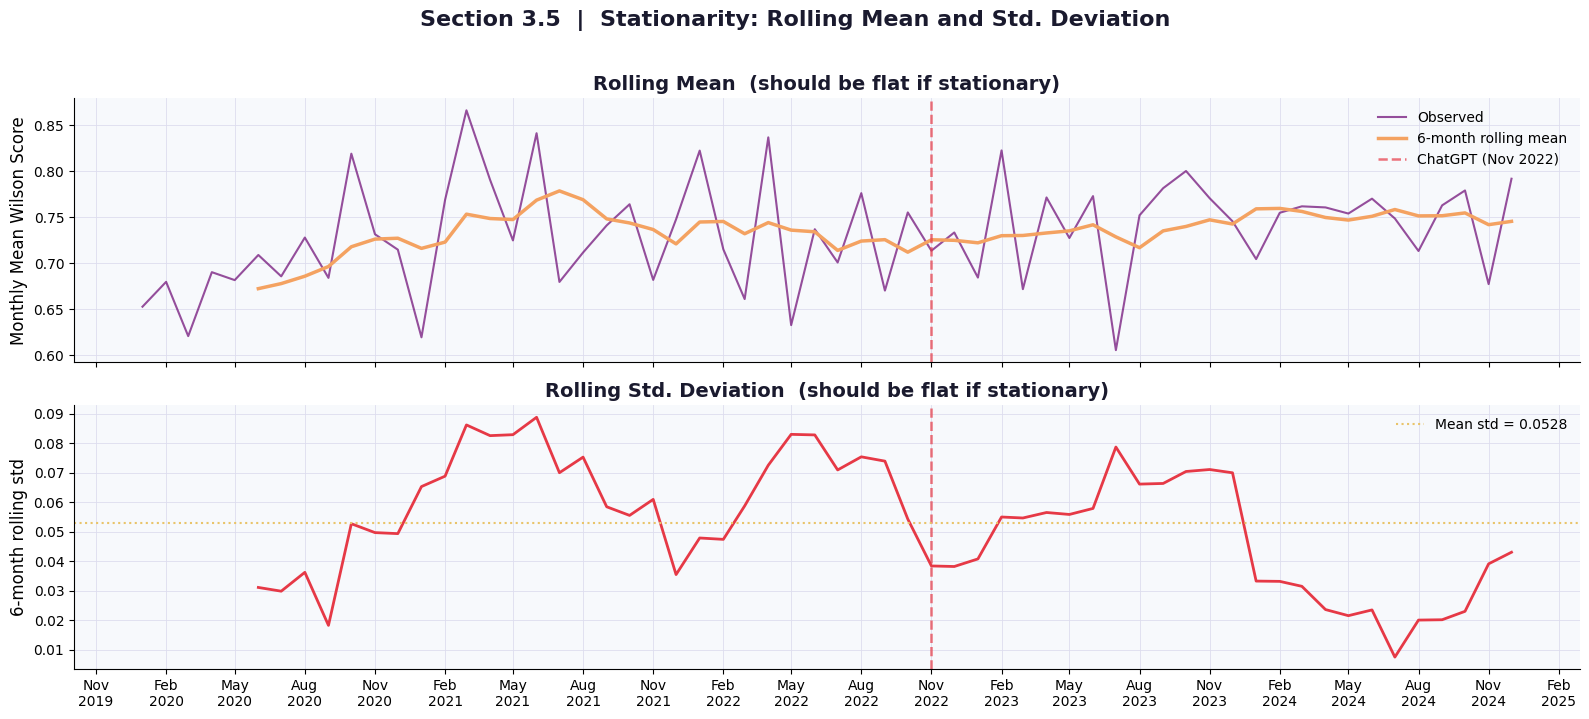

In [12]:
# ── Section 3.5 | Stationarity: Rolling Statistics ───────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle("Section 3.5  |  Stationarity: Rolling Mean and Std. Deviation",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.02)

# 6-month rolling window
roll_mean = ts.rolling(6).mean()
roll_std  = ts.rolling(6).std()

# ── Top: Rolling mean ─────────────────────────────────────────────────────────
axes[0].plot(ts.index, ts.values,
             color=PURPLE, linewidth=1.5, alpha=0.7, label="Observed")
axes[0].plot(roll_mean.index, roll_mean.values,
             color=ORANGE, linewidth=2.5, label="6-month rolling mean")
axes[0].axvline(CHATGPT_DATE, color=RED, linestyle="--",
                linewidth=1.8, alpha=0.7, label="ChatGPT (Nov 2022)")
axes[0].set_title("Rolling Mean  (should be flat if stationary)")
axes[0].set_ylabel("Monthly Mean Wilson Score")
axes[0].legend(fontsize=10)

# ── Bottom: Rolling std ───────────────────────────────────────────────────────
axes[1].plot(roll_std.index, roll_std.values,
             color=RED, linewidth=2)
axes[1].axvline(CHATGPT_DATE, color=RED, linestyle="--",
                linewidth=1.8, alpha=0.7)
axes[1].axhline(roll_std.mean(), color=GOLD, linestyle=":",
                linewidth=1.5, label=f"Mean std = {roll_std.mean():.4f}")
axes[1].set_title("Rolling Std. Deviation  (should be flat if stationary)")
axes[1].set_ylabel("6-month rolling std")
axes[1].legend(fontsize=10)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.tight_layout()
plt.show()

Augmented Dickey-Fuller Test (H0: series has a unit root = non-stationary)

Original series
  ADF Statistic : -1.9452
  p-value       : 0.3111
  Critical 1%   : -3.5715
  Critical 5%   : -2.9226
  Verdict       : NON-STATIONARY (fail to reject H0)

First difference
  ADF Statistic : -3.2709
  p-value       : 0.0162
  Critical 1%   : -3.5715
  Critical 5%   : -2.9226
  Verdict       : STATIONARY (reject H0)


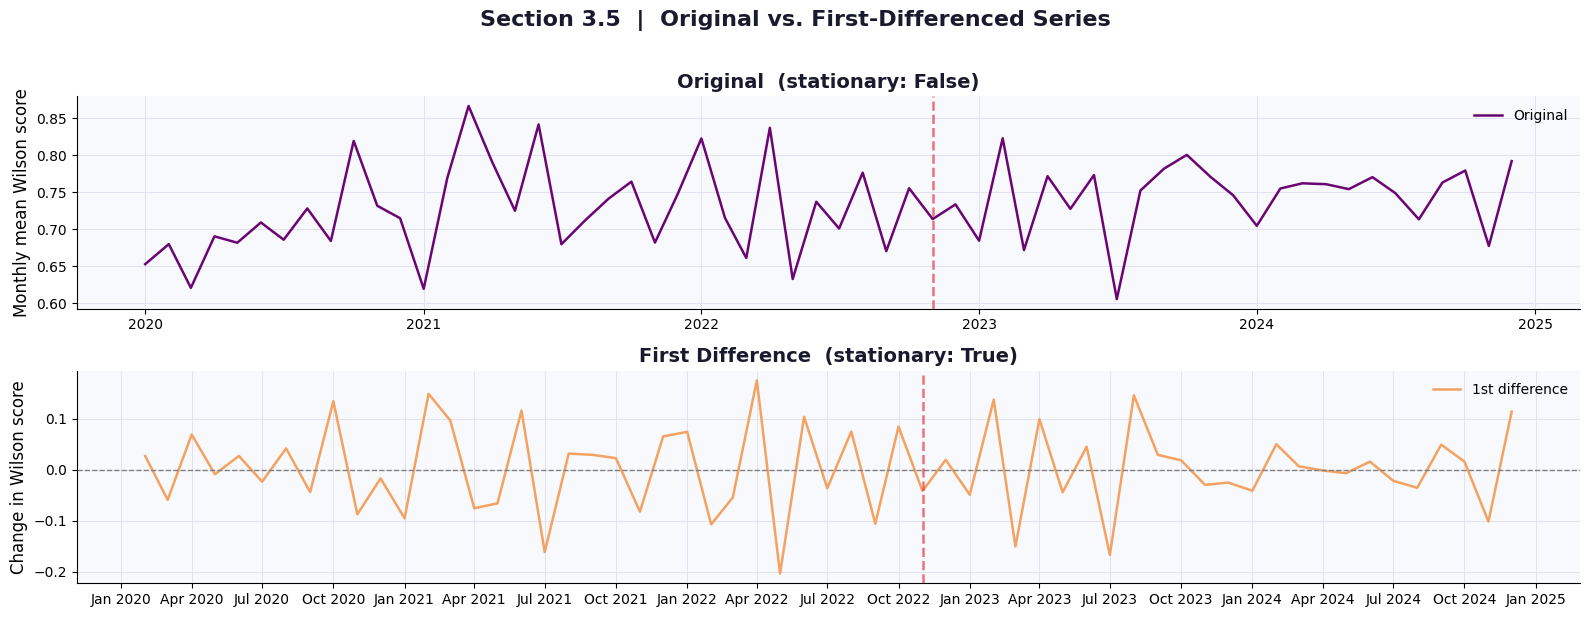

In [13]:
# ── Augmented Dickey-Fuller Test ──────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller

def adf_report(series, label):
    result = adfuller(series.dropna(), autolag="AIC")
    print(f"\n{label}")
    print(f"  ADF Statistic : {result[0]:.4f}")
    print(f"  p-value       : {result[1]:.4f}")
    print(f"  Critical 1%   : {result[4]['1%']:.4f}")
    print(f"  Critical 5%   : {result[4]['5%']:.4f}")
    verdict = "STATIONARY (reject H0)" if result[1] < 0.05 else "NON-STATIONARY (fail to reject H0)"
    print(f"  Verdict       : {verdict}")
    return result[1] < 0.05

print("Augmented Dickey-Fuller Test (H0: series has a unit root = non-stationary)")
print("=" * 65)
stat1 = adf_report(ts, "Original series")
diff1 = ts.diff().dropna()
stat2 = adf_report(diff1, "First difference")

fig, axes = plt.subplots(2, 1, figsize=(16, 6), sharex=False)
fig.suptitle("Section 3.5  |  Original vs. First-Differenced Series",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.02)

axes[0].plot(ts.index, ts.values, color=PURPLE, linewidth=1.8, label="Original")
axes[0].axvline(CHATGPT_DATE, color=RED, linestyle="--", linewidth=1.8, alpha=0.7)
axes[0].set_ylabel("Monthly mean Wilson score")
axes[0].legend(fontsize=10)
axes[0].set_title(f"Original  (stationary: {stat1})")

axes[1].plot(diff1.index, diff1.values, color=ORANGE, linewidth=1.8, label="1st difference")
axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)
axes[1].axvline(CHATGPT_DATE, color=RED, linestyle="--", linewidth=1.8, alpha=0.7)
axes[1].set_ylabel("Change in Wilson score")
axes[1].legend(fontsize=10)
axes[1].set_title(f"First Difference  (stationary: {stat2})")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.tight_layout()
plt.show()

### 3.6 &mdash; Autocorrelation (ACF) and Partial Autocorrelation (PACF)

<div class="callout">
<b>ACF</b> answers: how correlated is the series with itself <em>k</em> steps ago?<br>
<b>PACF</b> answers: how much does lag <em>k</em> contribute <em>after removing the influence of shorter lags?</em><br><br>
Together they reveal:<br>
&bull; Which lag features will be most useful<br>
&bull; Whether an autoregressive (AR) or moving average (MA) structure fits the data<br>
&bull; The seasonality period (spikes at regular lag intervals)
</div>


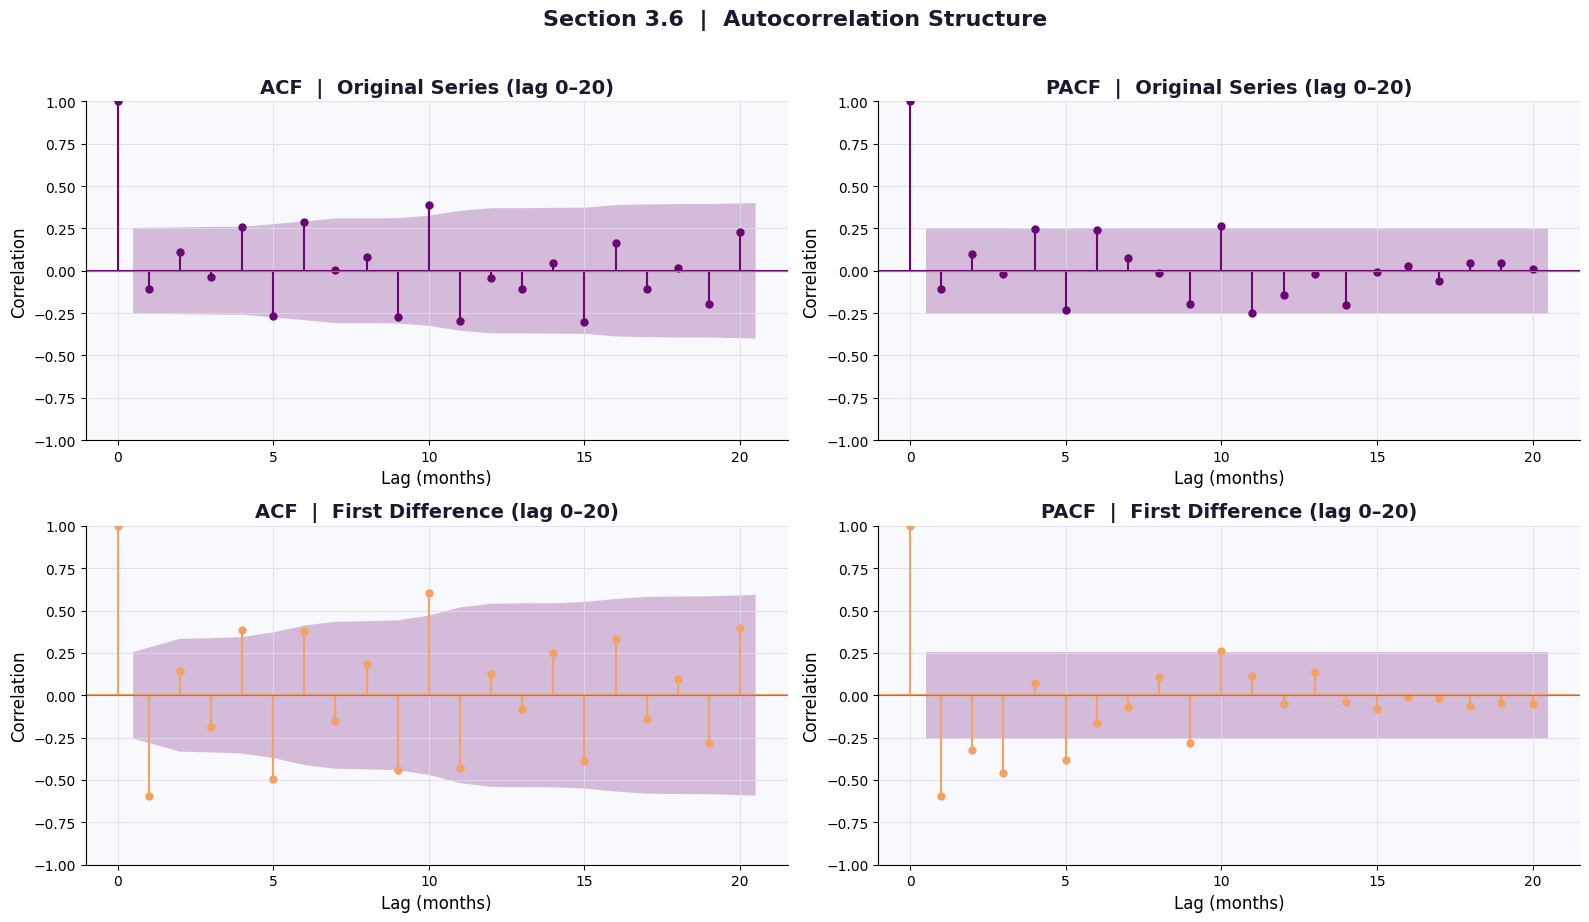

ACF / PACF reading guide:
  d = 1  (from ADF test — one difference is sufficient)

  Slow decay in original ACF        → trend present, take difference
  Spike at lag-1 in differenced ACF → suggests MA(1) component
  Spike at lag-1 in differenced PACF→ suggests AR(1) component
  Spike at lag-12                   → suggests S=12 seasonal component

→ Starting model suggestion: SARIMA(1,1,1)(1,0,1)[12]
  (to be optimised with auto_arima in Section 4)


In [14]:
# ── Section 3.6 | Autocorrelation Structure (ACF & PACF) ─────────────────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("Section 3.6  |  Autocorrelation Structure",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.02)

ts_diff = ts.diff().dropna()

# ── Top: Original series ACF & PACF ──────────────────────────────────────────
plot_acf(ts.dropna(), lags=20, ax=axes[0][0],
         color=PURPLE, vlines_kwargs={"colors": PURPLE})
axes[0][0].set_title("ACF  |  Original Series (lag 0–20)")
axes[0][0].set_xlabel("Lag (months)")

plot_pacf(ts.dropna(), lags=20, ax=axes[0][1],
          method="ywm", color=PURPLE, vlines_kwargs={"colors": PURPLE})
axes[0][1].set_title("PACF  |  Original Series (lag 0–20)")
axes[0][1].set_xlabel("Lag (months)")

# ── Bottom: First-differenced series ACF & PACF ───────────────────────────────
plot_acf(ts_diff.dropna(), lags=20, ax=axes[1][0],
         color=ORANGE, vlines_kwargs={"colors": ORANGE})
axes[1][0].set_title("ACF  |  First Difference (lag 0–20)")
axes[1][0].set_xlabel("Lag (months)")

plot_pacf(ts_diff.dropna(), lags=20, ax=axes[1][1],
          method="ywm", color=ORANGE, vlines_kwargs={"colors": ORANGE})
axes[1][1].set_title("PACF  |  First Difference (lag 0–20)")
axes[1][1].set_xlabel("Lag (months)")

for ax in axes.flatten():
    ax.set_ylabel("Correlation")
    ax.axhline(0, color="gray", linewidth=0.8)

plt.tight_layout()
plt.show()

# ── ARIMA parameter guidance ──────────────────────────────────────────────────
print("ACF / PACF reading guide:")
print("  d = 1  (from ADF test — one difference is sufficient)")
print()
print("  Slow decay in original ACF        → trend present, take difference")
print("  Spike at lag-1 in differenced ACF → suggests MA(1) component")
print("  Spike at lag-1 in differenced PACF→ suggests AR(1) component")
print("  Spike at lag-12                   → suggests S=12 seasonal component")
print()
print("→ Starting model suggestion: SARIMA(1,1,1)(1,0,1)[12]")
print("  (to be optimised with auto_arima in Section 4)")

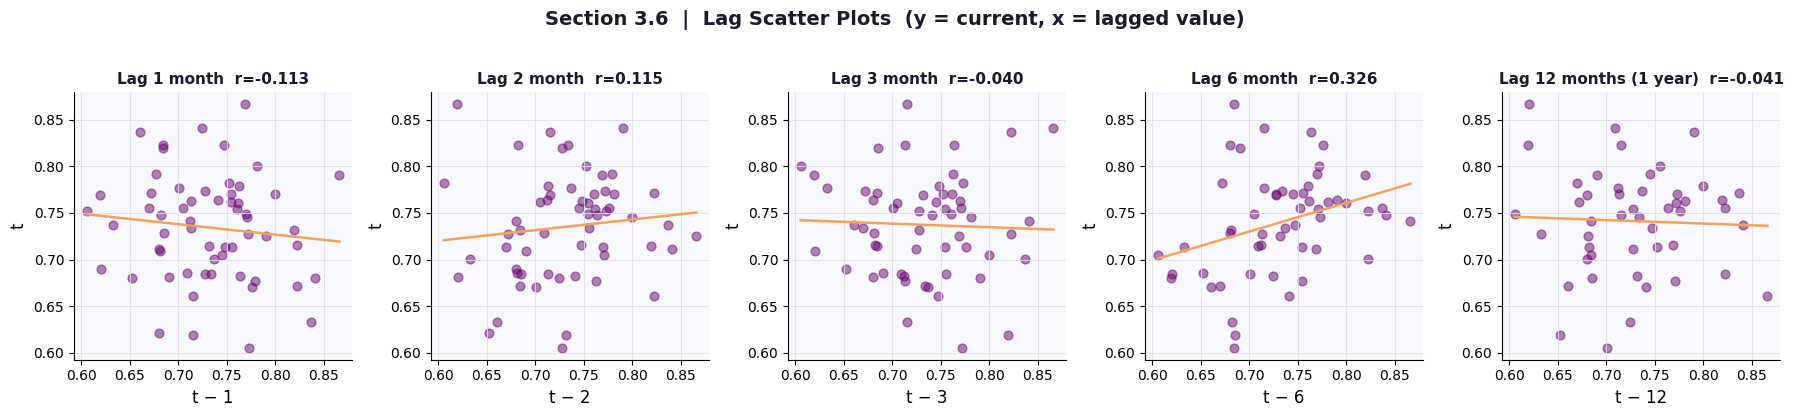

Lag              Correlation        Interpretation
--------------------------------------------------
1 month              -0.1130                  Weak
2 month               0.1145                  Weak
3 month              -0.0400                  Weak
6 month               0.3256              Moderate
12 months            -0.0408                  Weak


In [15]:
# ── Section 3.6 | Lag Scatter Plots ──────────────────────────────────────────
lags_to_show = [1, 2, 3, 6, 12]

fig, axes = plt.subplots(1, len(lags_to_show), figsize=(18, 4))
fig.suptitle("Section 3.6  |  Lag Scatter Plots  (y = current, x = lagged value)",
             fontsize=14, fontweight="bold", color="#1a1a2e", y=1.03)

for ax, lag in zip(axes, lags_to_show):
    x     = ts.shift(lag)
    y     = ts
    valid = x.notna() & y.notna()
    r     = np.corrcoef(x[valid], y[valid])[0, 1]

    ax.scatter(x[valid], y[valid], alpha=0.5, s=40, color=PURPLE)

    # Trend line
    z = np.polyfit(x[valid], y[valid], 1)
    p = np.poly1d(z)
    x_line = np.linspace(x[valid].min(), x[valid].max(), 100)
    ax.plot(x_line, p(x_line), color=ORANGE, linewidth=1.8)

    lag_label = f"{lag} month" if lag < 12 else "12 months (1 year)"
    ax.set_title(f"Lag {lag_label}  r={r:.3f}", fontsize=11)
    ax.set_xlabel(f"t − {lag}")
    ax.set_ylabel("t")

plt.tight_layout()
plt.show()

# ── Lag correlation summary ───────────────────────────────────────────────────
print(f"{'Lag':<15} {'Correlation':>12}  {'Interpretation':>20}")
print("-" * 50)
for lag in lags_to_show:
    x     = ts.shift(lag)
    valid = x.notna() & ts.notna()
    r     = np.corrcoef(x[valid], ts[valid])[0, 1]
    interp = ("Strong" if abs(r) > 0.5 else
              "Moderate" if abs(r) > 0.3 else
              "Weak")
    lag_label = f"{lag} month" if lag < 12 else "12 months"
    print(f"{lag_label:<15} {r:>12.4f}  {interp:>20}")

### 3.7 &mdash; Anomaly Detection

<div class="warning">
Anomalies in time series are more complex than outliers in cross-sectional data.<br>
An unusually high value on a hot summer afternoon might be completely normal.
The same value at 3am in winter is an anomaly. Context &mdash; time of day, day of week,
season &mdash; determines what is normal. Always compare against seasonal expectations,
not against the global mean.
</div>


In [16]:
# ── Section 3.7 | Anomaly Detection — Calculation ────────────────────────────
df_work = df[["wilson_mean", "game_count"]].copy()
df_work["month"] = df_work.index.month

season_stats = df_work.groupby("month")["wilson_mean"].agg(["mean", "std"])
df_work = df_work.join(season_stats, on="month")
df_work["z_score"] = (df_work["wilson_mean"] - df_work["mean"]) / df_work["std"]

THRESHOLD = 2.0
anomalies = df_work[df_work["z_score"].abs() > THRESHOLD]

print(f"Anomalies detected (|z| > {THRESHOLD}): {len(anomalies)}")
print(f"Percentage of total observations: {len(anomalies)/len(df_work)*100:.2f}%")

if len(anomalies) > 0:
    print("\nDetected anomalies:")
    display(anomalies[["wilson_mean", "mean", "std", "z_score", "game_count"]]
            .round(4)
            .sort_values("z_score"))
else:
    print("\n✓ No anomalies detected — all months within ±2 standard deviations.")

Anomalies detected (|z| > 2.0): 0
Percentage of total observations: 0.00%

✓ No anomalies detected — all months within ±2 standard deviations.


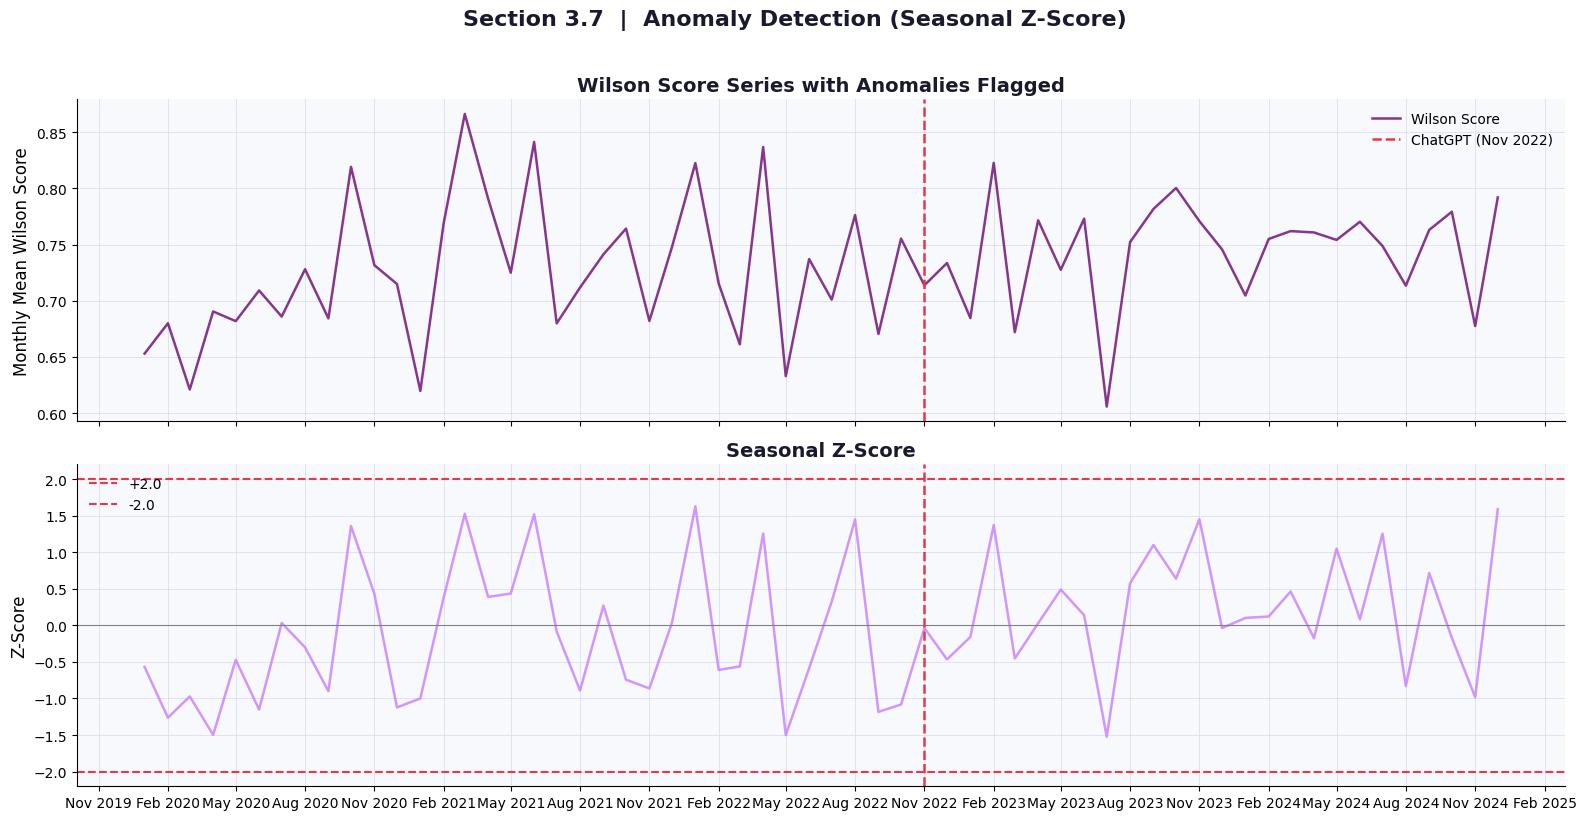

In [17]:
# ── Section 3.7 | Anomaly Detection — Visualisation ──────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle("Section 3.7  |  Anomaly Detection (Seasonal Z-Score)",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.02)

# ── Top: Series + anomaly points ─────────────────────────────────────────────
axes[0].plot(df_work.index, df_work["wilson_mean"],
             color=PURPLE, linewidth=1.8, alpha=0.8, label="Wilson Score")
axes[0].axvline(CHATGPT_DATE, color=RED, linestyle="--",
                linewidth=1.8, label="ChatGPT (Nov 2022)")

if len(anomalies) > 0:
    axes[0].scatter(anomalies.index, anomalies["wilson_mean"],
                    color=RED, s=120, zorder=5, marker="D",
                    label=f"Anomaly (|z| > {THRESHOLD})")
    for idx, row in anomalies.iterrows():
        axes[0].annotate(
            f"{idx.strftime('%b %Y')}\nz={row['z_score']:.2f}",
            (idx, row["wilson_mean"]),
            textcoords="offset points", xytext=(0, 12),
            fontsize=8, ha="center", color=RED, fontweight="bold"
        )

axes[0].set_title("Wilson Score Series with Anomalies Flagged")
axes[0].set_ylabel("Monthly Mean Wilson Score")
axes[0].legend(fontsize=10)
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# ── Bottom: Z-score series ────────────────────────────────────────────────────
axes[1].plot(df_work.index, df_work["z_score"],
             color=VIOLET, linewidth=1.8, alpha=0.8)
axes[1].axhline( THRESHOLD, color=RED, linestyle="--",
                linewidth=1.5, label=f"+{THRESHOLD}")
axes[1].axhline(-THRESHOLD, color=RED, linestyle="--",
                linewidth=1.5, label=f"-{THRESHOLD}")
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].axvline(CHATGPT_DATE, color=RED, linestyle="--", linewidth=1.8)
axes[1].fill_between(df_work.index, df_work["z_score"], 0,
                     where=df_work["z_score"].abs() > THRESHOLD,
                     color=RED, alpha=0.3)
axes[1].set_title("Seasonal Z-Score")
axes[1].set_ylabel("Z-Score")
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

 ### Section 3.8 &mdash;  — Advanced Statistical Tests
 

In [18]:
# ── Section 3.8 | Chow Test — Structural Break Analysis ──────────────────────
# H0: No structural break at November 2022
# H1: A significant structural break exists at November 2022
from scipy import stats

pre  = ts[ts.index <  CHATGPT_DATE].values
post = ts[ts.index >= CHATGPT_DATE].values
full = ts.values
n1, n2, n = len(pre), len(post), len(full)

def ols_rss(y):
    x = np.arange(len(y))
    X = np.column_stack([np.ones(len(y)), x])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    resid = y - X @ beta
    return np.sum(resid**2), len(beta)

rss_full,  k_full  = ols_rss(full)
rss_pre,   k_pre   = ols_rss(pre)
rss_post,  k_post  = ols_rss(post)

rss_restricted   = rss_full
rss_unrestricted = rss_pre + rss_post

k      = k_full
chow_f = ((rss_restricted - rss_unrestricted) / k) / \
          (rss_unrestricted / (n - 2 * k))
chow_p = 1 - stats.f.cdf(chow_f, dfn=k, dfd=n - 2 * k)

print("=" * 55)
print("  Chow Test — Structural Break (November 2022)")
print("=" * 55)
print(f"  RSS (restricted, full model)   : {rss_restricted:.6f}")
print(f"  RSS (unrestricted, pre + post) : {rss_unrestricted:.6f}")
print(f"  F statistic                    : {chow_f:.4f}")
print(f"  p-value                        : {chow_p:.4f}")
print(f"  Degrees of freedom             : ({k}, {n - 2*k})")
print("-" * 55)
if chow_p < 0.05:
    print("  → H0 REJECTED: Significant structural break detected")
    print("    at November 2022 (p < 0.05) ✓")
else:
    print("  → H0 NOT REJECTED: No statistically significant")
    print(f"    structural break found (p = {chow_p:.4f})")
print("=" * 55)

  Chow Test — Structural Break (November 2022)
  RSS (restricted, full model)   : 0.180217
  RSS (unrestricted, pre + post) : 0.177993
  F statistic                    : 0.3500
  p-value                        : 0.7062
  Degrees of freedom             : (2, 56)
-------------------------------------------------------
  → H0 NOT REJECTED: No statistically significant
    structural break found (p = 0.7062)


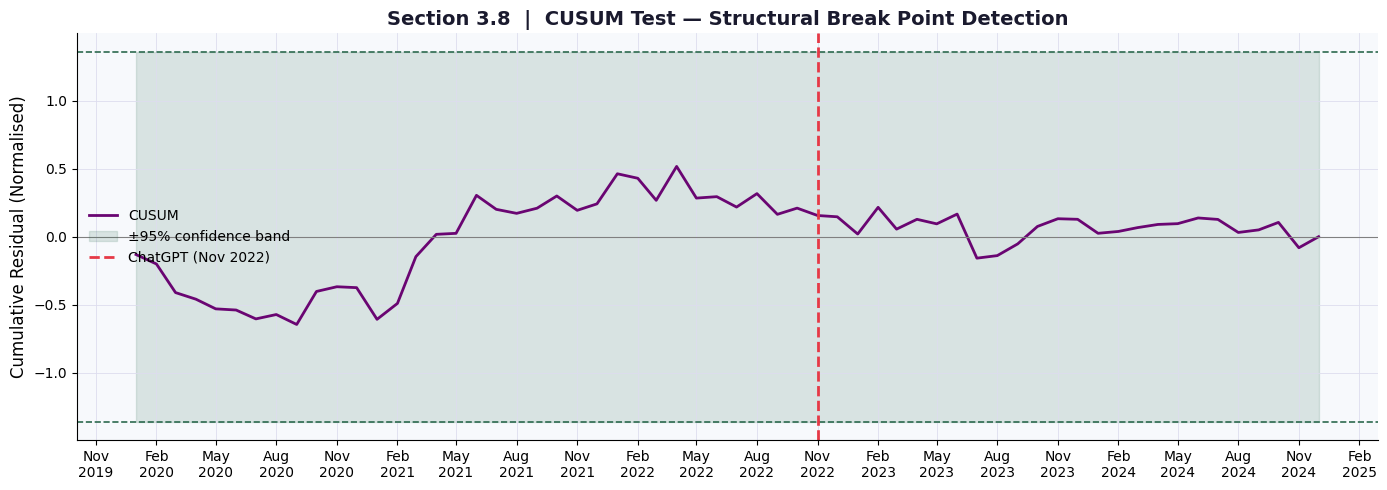

Band violations    : 0


In [19]:
# ── Section 3.8 | CUSUM Test — Break Point Detection ─────────────────────────
import statsmodels.api as sm

x_full = np.arange(len(ts))
X_full = sm.add_constant(x_full)
model  = sm.OLS(ts.values, X_full).fit()
resids = model.resid

cusum       = np.cumsum(resids) / (resids.std() * np.sqrt(len(resids)))
cusum_dates = ts.index
n_obs       = len(resids)
bound       = 1.36 * np.ones(n_obs)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(cusum_dates, cusum, color=PURPLE, linewidth=2, label="CUSUM")
ax.fill_between(cusum_dates, -bound, bound,
                alpha=0.15, color=TEAL, label="±95% confidence band")
ax.axhline( 1.36, color=TEAL, linestyle="--", linewidth=1.2)
ax.axhline(-1.36, color=TEAL, linestyle="--", linewidth=1.2)
ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(CHATGPT_DATE, color=RED, linestyle="--",
           linewidth=2, label="ChatGPT (Nov 2022)")

breach = np.where(np.abs(cusum) > 1.36)[0]
if len(breach) > 0:
    ax.scatter(cusum_dates[breach], cusum[breach],
               color=RED, s=60, zorder=5, label="Band violation")
    first_breach = cusum_dates[breach[0]]
    ax.annotate(f"First violation:\n{first_breach.strftime('%b %Y')}",
                (first_breach, cusum[breach[0]]),
                textcoords="offset points", xytext=(10, 10),
                fontsize=9, color=RED, fontweight="bold")

ax.set_title("Section 3.8  |  CUSUM Test — Structural Break Point Detection",
             fontsize=14, fontweight="bold", color="#1a1a2e")
ax.set_ylabel("Cumulative Residual (Normalised)")
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.tight_layout()
plt.show()

print(f"Band violations    : {len(breach)}")
if len(breach) > 0:
    print(f"First violation    : {first_breach.strftime('%B %Y')}")
    print(f"ChatGPT date       : November 2022")
    diff_months = abs((first_breach.year  - CHATGPT_DATE.year) * 12 +
                      (first_breach.month - CHATGPT_DATE.month))
    print(f"Difference         : {diff_months} months")

In [20]:
# ── Section 3.8 | Mann-Whitney U Test ────────────────────────────────────────
# Non-parametric alternative to t-test — no normality assumption required
# H0: Pre and post period distributions are identical
from scipy.stats import mannwhitneyu

pre_vals  = ts[ts.index <  CHATGPT_DATE].values
post_vals = ts[ts.index >= CHATGPT_DATE].values

mw_stat, mw_p = mannwhitneyu(pre_vals, post_vals, alternative="two-sided")

n1, n2   = len(pre_vals), len(post_vals)
r_effect = 1 - (2 * mw_stat) / (n1 * n2)

print("=" * 55)
print("  Mann-Whitney U Test (Pre vs Post ChatGPT)")
print("=" * 55)
print(f"  U statistic     : {mw_stat:.1f}")
print(f"  p-value         : {mw_p:.4f}")
print(f"  Effect size     : r = {r_effect:.4f}")
print(f"  Pre  median     : {np.median(pre_vals):.4f}")
print(f"  Post median     : {np.median(post_vals):.4f}")
print("-" * 55)
if mw_p < 0.05:
    print("  → H0 REJECTED: Distributions are significantly different (p < 0.05)")
else:
    print(f"  → H0 NOT REJECTED (p = {mw_p:.4f})")
effect_label = ("Small"  if abs(r_effect) < 0.3 else
                "Medium" if abs(r_effect) < 0.5 else "Large")
print(f"  Effect size     : {effect_label} ({abs(r_effect):.3f})")
print("=" * 55)

  Mann-Whitney U Test (Pre vs Post ChatGPT)
  U statistic     : 328.0
  p-value         : 0.0904
  Effect size     : r = 0.2579
  Pre  median     : 0.7151
  Post median     : 0.7545
-------------------------------------------------------
  → H0 NOT REJECTED (p = 0.0904)
  Effect size     : Small (0.258)


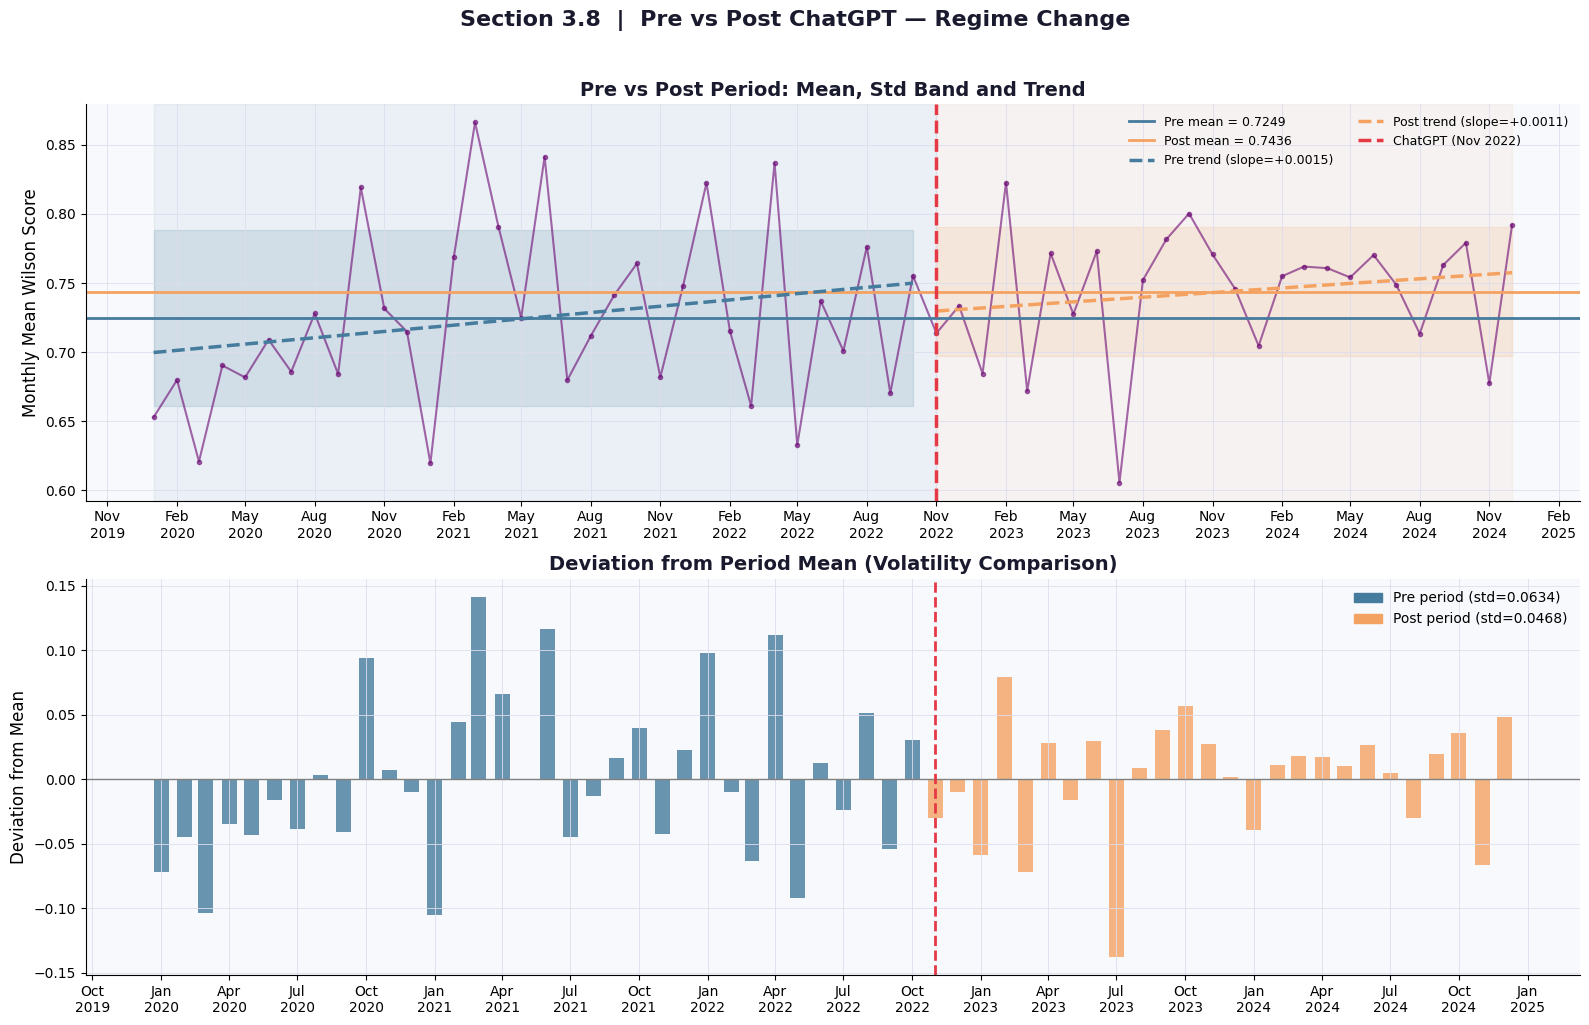

Metric                       Pre-ChatGPT    Post-ChatGPT        Diff
--------------------------------------------------------------------
Mean                              0.7249          0.7436     +0.0188
Median                            0.7151          0.7545     +0.0394
Std. Dev                          0.0634          0.0468     -0.0167
Min                               0.6196          0.6057     -0.0139
Max                               0.8662          0.8226     -0.0436


In [21]:
# ── Section 3.8 | Regime Change Visualisation ────────────────────────────────
from scipy import stats as sp_stats

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle("Section 3.8  |  Pre vs Post ChatGPT — Regime Change",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.02)

pre_s  = ts[ts.index <  CHATGPT_DATE]
post_s = ts[ts.index >= CHATGPT_DATE]

# ── Top: Series + confidence bands + trend lines ──────────────────────────────
ax = axes[0]

ax.axvspan(ts.index.min(), CHATGPT_DATE, alpha=0.07, color=BLUE)
ax.axvspan(CHATGPT_DATE, ts.index.max(), alpha=0.07, color=ORANGE)

ax.plot(ts.index, ts.values, color=PURPLE, linewidth=1.5,
        alpha=0.6, marker="o", markersize=3)

ax.axhline(pre_s.mean(), color=BLUE, linewidth=2,
           linestyle="-", label=f"Pre mean = {pre_s.mean():.4f}")
ax.fill_between(pre_s.index,
                pre_s.mean() - pre_s.std(),
                pre_s.mean() + pre_s.std(),
                alpha=0.15, color=BLUE)

ax.axhline(post_s.mean(), color=ORANGE, linewidth=2,
           linestyle="-", label=f"Post mean = {post_s.mean():.4f}")
ax.fill_between(post_s.index,
                post_s.mean() - post_s.std(),
                post_s.mean() + post_s.std(),
                alpha=0.15, color=ORANGE)

for segment, color, label in [
    (pre_s,  BLUE,   "Pre trend"),
    (post_s, ORANGE, "Post trend")
]:
    x_num = np.arange(len(segment))
    slope, intercept, r, p, _ = sp_stats.linregress(x_num, segment.values)
    trend_line = intercept + slope * x_num
    ax.plot(segment.index, trend_line, color=color,
            linewidth=2.5, linestyle="--",
            label=f"{label} (slope={slope:+.4f})")

ax.axvline(CHATGPT_DATE, color=RED, linestyle="--",
           linewidth=2.5, label="ChatGPT (Nov 2022)")
ax.set_title("Pre vs Post Period: Mean, Std Band and Trend")
ax.set_ylabel("Monthly Mean Wilson Score")
ax.legend(fontsize=9, ncol=2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

# ── Bottom: Deviation from period mean (volatility comparison) ────────────────
ax2 = axes[1]

pre_centered  = pre_s  - pre_s.mean()
post_centered = post_s - post_s.mean()
centered      = pd.concat([pre_centered, post_centered])

colors = [BLUE if d < CHATGPT_DATE else ORANGE for d in centered.index]
ax2.bar(centered.index, centered.values,
        color=colors, width=20, alpha=0.8)
ax2.axhline(0, color="gray", linewidth=1)
ax2.axvline(CHATGPT_DATE, color=RED, linestyle="--", linewidth=2)

pre_patch  = plt.matplotlib.patches.Patch(
    color=BLUE,   label=f"Pre period (std={pre_s.std():.4f})")
post_patch = plt.matplotlib.patches.Patch(
    color=ORANGE, label=f"Post period (std={post_s.std():.4f})")
ax2.legend(handles=[pre_patch, post_patch], fontsize=10)
ax2.set_title("Deviation from Period Mean (Volatility Comparison)")
ax2.set_ylabel("Deviation from Mean")
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"{'Metric':<25} {'Pre-ChatGPT':>14}  {'Post-ChatGPT':>14}  {'Diff':>10}")
print("-" * 68)
metrics = [
    ("Mean",       pre_s.mean(),   post_s.mean()),
    ("Median",     pre_s.median(), post_s.median()),
    ("Std. Dev",   pre_s.std(),    post_s.std()),
    ("Min",        pre_s.min(),    post_s.min()),
    ("Max",        pre_s.max(),    post_s.max()),
]
for name, pre_v, post_v in metrics:
    print(f"{name:<25} {pre_v:>14.4f}  {post_v:>14.4f}  "
          f"{post_v-pre_v:>+10.4f}")

Strongest break date   : July 2021
F statistic            : 5.9669
p-value                : 0.0045


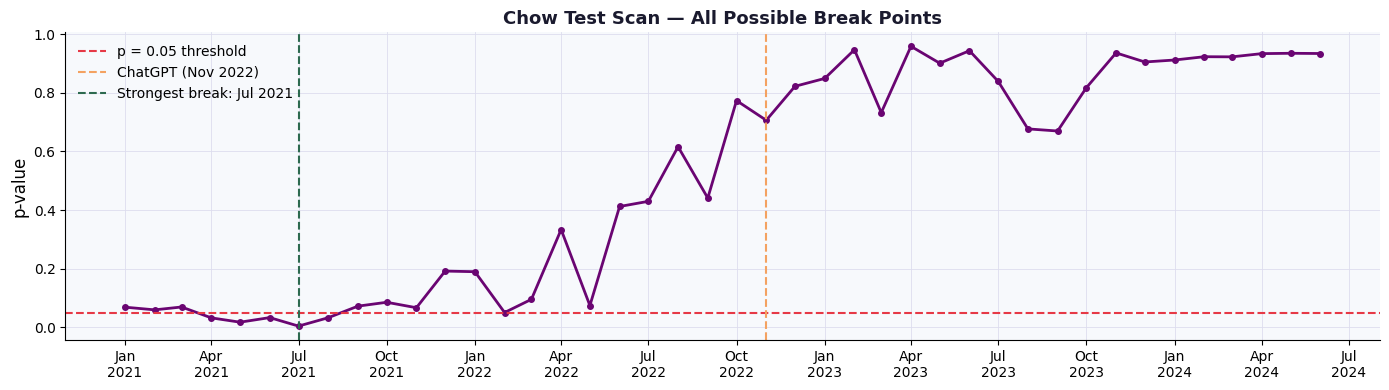

In [22]:
# ── Chow Test Scan — All Possible Break Points ────────────────────────────────
results = []

for break_date in pd.date_range("2021-01-01", "2024-06-01", freq="MS"):
    seg1 = ts[ts.index <  break_date].values
    seg2 = ts[ts.index >= break_date].values

    if len(seg1) < 6 or len(seg2) < 6:
        continue

    rss_full, k  = ols_rss(ts.values)
    rss_pre,  _  = ols_rss(seg1)
    rss_post, _  = ols_rss(seg2)
    rss_unres    = rss_pre + rss_post

    n = len(ts)
    f = ((rss_full - rss_unres) / k) / (rss_unres / (n - 2*k))
    p = 1 - stats.f.cdf(f, dfn=k, dfd=n - 2*k)

    results.append({"date": break_date, "F": f, "p": p})

results_df = pd.DataFrame(results).set_index("date")

# Strongest break point
best = results_df.loc[results_df["F"].idxmax()]
print(f"Strongest break date   : {results_df['F'].idxmax().strftime('%B %Y')}")
print(f"F statistic            : {best['F']:.4f}")
print(f"p-value                : {best['p']:.4f}")

# Visualise
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(results_df.index, results_df["p"],
        color=PURPLE, linewidth=2, marker="o", markersize=4)
ax.axhline(0.05, color=RED, linestyle="--",
           linewidth=1.5, label="p = 0.05 threshold")
ax.axvline(CHATGPT_DATE, color=ORANGE, linestyle="--",
           linewidth=1.5, label="ChatGPT (Nov 2022)")
ax.axvline(results_df["F"].idxmax(), color=TEAL, linestyle="--",
           linewidth=1.5, label=f"Strongest break: "
           f"{results_df['F'].idxmax().strftime('%b %Y')}")
ax.set_title("Chow Test Scan — All Possible Break Points",
             fontsize=13, fontweight="bold", color="#1a1a2e")
ax.set_ylabel("p-value")
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.tight_layout()
plt.show()

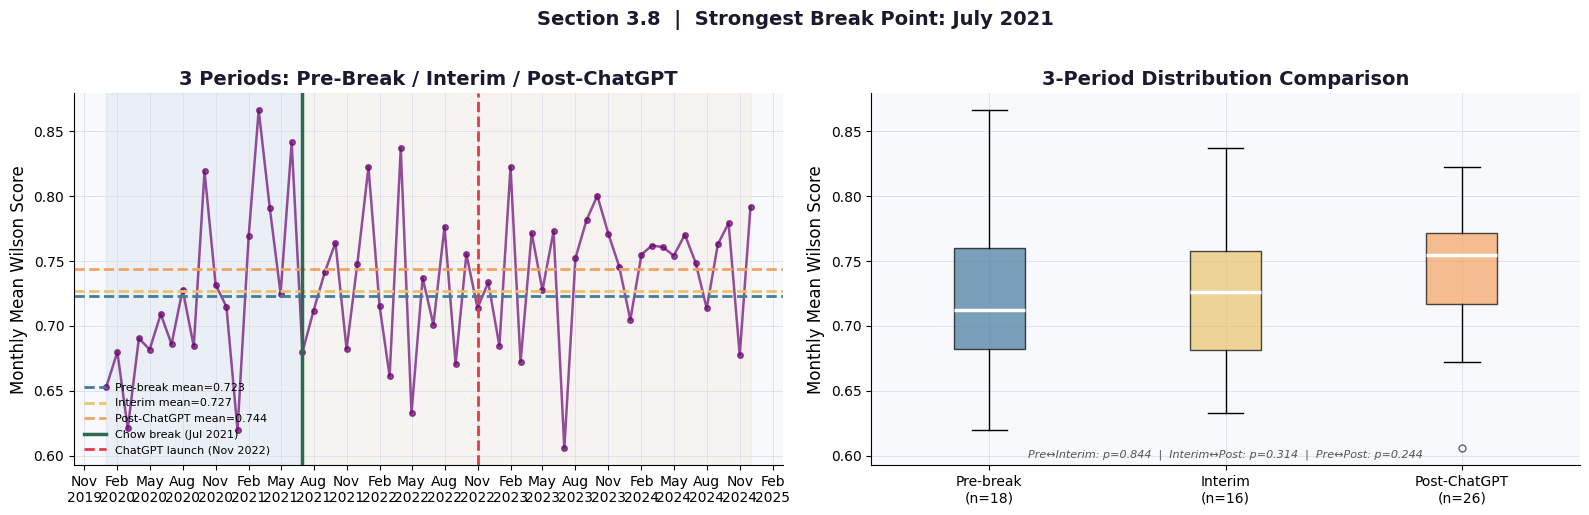

Period                            n      Mean       Std       Min       Max
----------------------------------------------------------------------
Pre-break (< Jul 2021)           18    0.7228    0.0704    0.6196    0.8662
Interim (Jul 2021 – Oct 22)      16    0.7272    0.0567    0.6329    0.8368
Post-ChatGPT (≥ Nov 2022)        26    0.7436    0.0468    0.6057    0.8226

→ Strongest statistical break: July 2021
→ 16 months before the ChatGPT launch
  Likely reflects broader AI tool proliferation (Midjourney, Copilot)
  rather than ChatGPT specifically


In [23]:
# ── Break Point Detail Analysis ───────────────────────────────────────────────
BREAK_DATE = results_df["F"].idxmax()  # Use the date found by the Chow scan

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f"Section 3.8  |  Strongest Break Point: {BREAK_DATE.strftime('%B %Y')}",
             fontsize=14, fontweight="bold", color="#1a1a2e", y=1.02)

seg1 = ts[ts.index <  BREAK_DATE]
seg2 = ts[(ts.index >= BREAK_DATE) & (ts.index < CHATGPT_DATE)]
seg3 = ts[ts.index >= CHATGPT_DATE]

# ── Left: 3-period comparison ─────────────────────────────────────────────────
ax = axes[0]
ax.axvspan(ts.index.min(), BREAK_DATE,   alpha=0.08, color=BLUE)
ax.axvspan(BREAK_DATE, CHATGPT_DATE,     alpha=0.08, color=GOLD)
ax.axvspan(CHATGPT_DATE, ts.index.max(), alpha=0.08, color=ORANGE)

ax.plot(ts.index, ts.values, color=PURPLE, linewidth=1.8,
        alpha=0.7, marker="o", markersize=4)

for seg, color, label in [
    (seg1, BLUE,   f"Pre-break mean={seg1.mean():.3f}"),
    (seg2, GOLD,   f"Interim mean={seg2.mean():.3f}"),
    (seg3, ORANGE, f"Post-ChatGPT mean={seg3.mean():.3f}"),
]:
    ax.axhline(seg.mean(), color=color, linewidth=2,
               linestyle="--", label=label)

ax.axvline(BREAK_DATE, color=TEAL, linestyle="-",
           linewidth=2.5, label=f"Chow break ({BREAK_DATE.strftime('%b %Y')})")
ax.axvline(CHATGPT_DATE, color=RED, linestyle="--",
           linewidth=2, label="ChatGPT launch (Nov 2022)")
ax.set_title("3 Periods: Pre-Break / Interim / Post-ChatGPT")
ax.set_ylabel("Monthly Mean Wilson Score")
ax.legend(fontsize=8, loc="lower left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

# ── Right: 3-period box plot ──────────────────────────────────────────────────
ax2 = axes[1]
bp = ax2.boxplot(
    [seg1.values, seg2.values, seg3.values],
    patch_artist=True,
    labels=[f"Pre-break\n(n={len(seg1)})",
            f"Interim\n(n={len(seg2)})",
            f"Post-ChatGPT\n(n={len(seg3)})"],
    medianprops={"color": "white", "linewidth": 2.5},
    flierprops={"marker": "o", "markersize": 5, "alpha": 0.6},
)
for patch, color in zip(bp["boxes"], [BLUE, GOLD, ORANGE]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax2.set_title("3-Period Distribution Comparison")
ax2.set_ylabel("Monthly Mean Wilson Score")

t12, p12 = stats.ttest_ind(seg1, seg2)
t23, p23 = stats.ttest_ind(seg2, seg3)
t13, p13 = stats.ttest_ind(seg1, seg3)
ax2.text(0.5, 0.02,
         f"Pre↔Interim: p={p12:.3f}  |  Interim↔Post: p={p23:.3f}  |  Pre↔Post: p={p13:.3f}",
         transform=ax2.transAxes, ha="center", fontsize=8,
         color="#555", style="italic")

plt.tight_layout()
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"{'Period':<30} {'n':>4}  {'Mean':>8}  {'Std':>8}  {'Min':>8}  {'Max':>8}")
print("-" * 70)
for name, seg in [
    (f"Pre-break (< {BREAK_DATE.strftime('%b %Y')})",  seg1),
    (f"Interim ({BREAK_DATE.strftime('%b %Y')} – Oct 22)", seg2),
    ("Post-ChatGPT (≥ Nov 2022)",                      seg3),
]:
    print(f"{name:<30} {len(seg):>4}  {seg.mean():>8.4f}  "
          f"{seg.std():>8.4f}  {seg.min():>8.4f}  {seg.max():>8.4f}")

diff_months = abs((BREAK_DATE.year  - CHATGPT_DATE.year) * 12 +
                  (BREAK_DATE.month - CHATGPT_DATE.month))
print(f"\n→ Strongest statistical break: {BREAK_DATE.strftime('%B %Y')}")
print(f"→ {diff_months} months before the ChatGPT launch")
print(f"  Likely reflects broader AI tool proliferation (Midjourney, Copilot)")
print(f"  rather than ChatGPT specifically")

---
## Section 4 — Feature Engineering

<div class="callout">
Time series feature engineering is fundamentally different from cross-sectional feature engineering.
Instead of encoding existing columns, we <b>create new columns from the timestamp and the history</b>.<br><br>
The two main families are:<br>
&bull; <b>Calendar features</b> &mdash; derived from the timestamp (month, quarter, year, season, post_chatgpt)<br>
&bull; <b>Lag and window features</b> &mdash; derived from past values of the monthly Wilson score series
</div>

| Step | Technique | Why it matters |
|---|---|---|
| 4.1 | Handle missing timestamps | Lags computed on gappy data are silently wrong |
| 4.2 | Calendar features | Capture known seasonality and the ChatGPT structural break explicitly |
| 4.3 | Lag features | Give the model direct access to recent history |
| 4.4 | Rolling window features | Smooth short-term noise; capture recent trend and volatility |
| 4.5 | Train / test split | Must be chronological — never random |

### 4.1 &mdash; Handling Missing Timestamps


In [24]:
# ── Section 4.1 | Missing Timestamp Check ────────────────────────────────────
# Missing values were already checked in Section 3.2.
# df was reindexed with full_idx and a was_missing flag was created.
# This cell performs a final validation before feature engineering.

print(f"Series length      : {len(df)} monthly slots")
print(f"Remaining NaN      : {df['wilson_mean'].isna().sum()}")
print(f"Interpolated slots : {df['was_missing'].sum()}")

still_missing = df["wilson_mean"].isna().sum()
if still_missing > 0:
    print(f"\nWARNING: {still_missing} value(s) could not be filled.")
    print("Options: increase interpolation limit or drop the affected rows.")
else:
    print("\nAll slots filled. Ready for feature engineering.")

Series length      : 60 monthly slots
Remaining NaN      : 0
Interpolated slots : 0

All slots filled. Ready for feature engineering.


### 4.2 &mdash; Calendar Features


In [25]:
# ── Section 4.2 | Calendar Features ──────────────────────────────────────────
df_feat = df[["wilson_mean", "wilson_median", "game_count", "was_missing"]].copy()

# ── Basic calendar features ───────────────────────────────────────────────────
df_feat["month"]              = df_feat.index.month
df_feat["quarter"]            = df_feat.index.quarter
df_feat["year"]               = df_feat.index.year
df_feat["post_chatgpt"]       = (df_feat.index >= CHATGPT_DATE).astype(int)
df_feat["months_from_chatgpt"] = (
    (df_feat.index.year  - CHATGPT_DATE.year) * 12 +
    (df_feat.index.month - CHATGPT_DATE.month)
)

# ── Season feature ────────────────────────────────────────────────────────────
season_map = {12: 0, 1: 0, 2: 0,   # Winter
               3: 1, 4: 1, 5: 1,   # Spring
               6: 2, 7: 2, 8: 2,   # Summer
               9: 3, 10: 3, 11: 3} # Autumn
df_feat["season"] = df_feat["month"].map(season_map)

# ── Cyclical encoding ─────────────────────────────────────────────────────────
# January and December are neighbours — a linear feature cannot capture this
df_feat["month_sin"]   = np.sin(2 * np.pi * df_feat["month"]   / 12)
df_feat["month_cos"]   = np.cos(2 * np.pi * df_feat["month"]   / 12)
df_feat["quarter_sin"] = np.sin(2 * np.pi * df_feat["quarter"] / 4)
df_feat["quarter_cos"] = np.cos(2 * np.pi * df_feat["quarter"] / 4)

print("Calendar features created:")
print(df_feat.filter(
    regex="month|quarter|year|season|post|chatgpt|sin|cos"
).columns.tolist())
print(f"\ndf_feat shape: {df_feat.shape}")
print(f"\nFirst 5 rows:")
display(df_feat.head())

Calendar features created:
['was_missing', 'month', 'quarter', 'year', 'post_chatgpt', 'months_from_chatgpt', 'season', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos']

df_feat shape: (60, 14)

First 5 rows:


,wilson_mean,wilson_median,game_count,was_missing,month,quarter,year,post_chatgpt,months_from_chatgpt,season,month_sin,month_cos,quarter_sin,quarter_cos
release_year_month,,,,,,,,,,,,,,
2020-01-01,0.652900,0.6599,7,0,1,1,2020,0,-34,0,0.500000,8.660254e-01,1.000000e+00,6.123234e-17
2020-02-01,0.679900,0.6751,13,0,2,1,2020,0,-33,0,0.866025,5.000000e-01,1.000000e+00,6.123234e-17
2020-03-01,0.620947,0.6337,15,0,3,1,2020,0,-32,1,1.000000,6.123234e-17,1.000000e+00,6.123234e-17
2020-04-01,0.690408,0.7519,13,0,4,2,2020,0,-31,1,0.866025,-5.000000e-01,1.224647e-16,-1.000000e+00
2020-05-01,0.681782,0.6425,11,0,5,2,2020,0,-30,1,0.500000,-8.660254e-01,1.224647e-16,-1.000000e+00


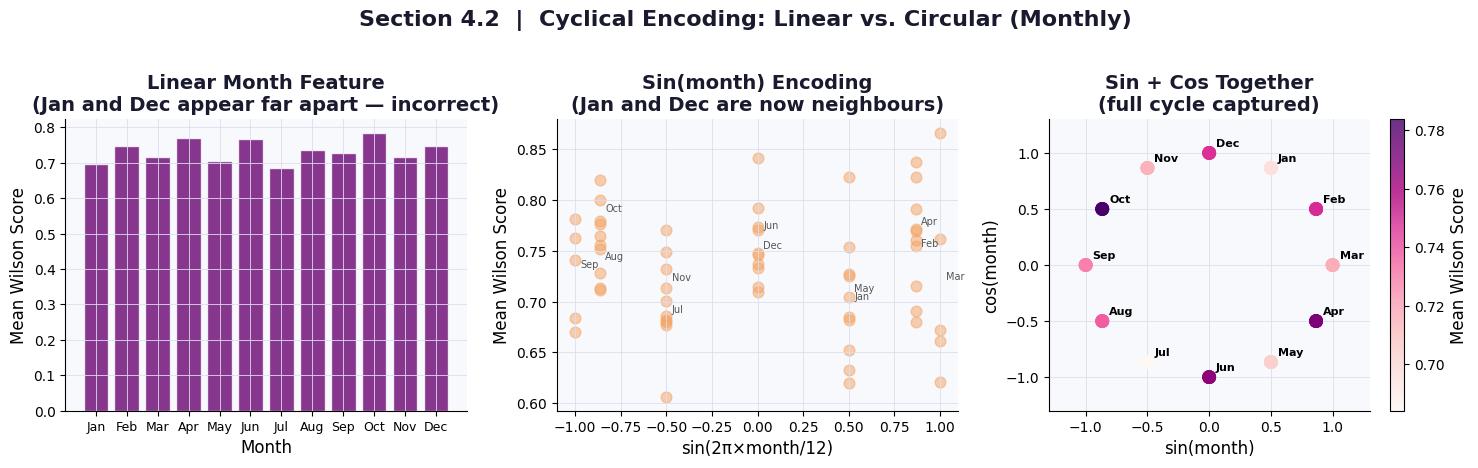

In [26]:
# ── Section 4.2 | Cyclical Encoding Visualisation ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle("Section 4.2  |  Cyclical Encoding: Linear vs. Circular (Monthly)",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.03)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
month_mean = df_feat.groupby("month")["wilson_mean"].mean()

# ── Left: Linear month feature ────────────────────────────────────────────────
axes[0].bar(month_mean.index, month_mean.values,
            color=PURPLE, alpha=0.8, edgecolor="white")
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_labels, fontsize=9)
axes[0].set_title("Linear Month Feature\n(Jan and Dec appear far apart — incorrect)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Mean Wilson Score")

# ── Middle: Sin encoding ──────────────────────────────────────────────────────
axes[1].scatter(df_feat["month_sin"], df_feat["wilson_mean"],
                alpha=0.5, s=60, color=ORANGE)
for m in range(1, 13):
    sin_val  = np.sin(2 * np.pi * m / 12)
    mean_val = month_mean[m]
    axes[1].annotate(month_labels[m-1],
                     (sin_val, mean_val),
                     textcoords="offset points",
                     xytext=(4, 4), fontsize=7, color="#555")
axes[1].set_title("Sin(month) Encoding\n(Jan and Dec are now neighbours)")
axes[1].set_xlabel("sin(2π×month/12)")
axes[1].set_ylabel("Mean Wilson Score")

# ── Right: Sin + Cos together (full circle) ───────────────────────────────────
sc = axes[2].scatter(df_feat["month_sin"], df_feat["month_cos"],
                     c=df_feat["month"].map(month_mean),
                     cmap="RdPu", s=80, alpha=0.8, zorder=3)
plt.colorbar(sc, ax=axes[2], label="Mean Wilson Score")

for m in range(1, 13):
    sin_val = np.sin(2 * np.pi * m / 12)
    cos_val = np.cos(2 * np.pi * m / 12)
    axes[2].annotate(month_labels[m-1],
                     (sin_val, cos_val),
                     textcoords="offset points",
                     xytext=(5, 5), fontsize=8, fontweight="bold")
axes[2].set_title("Sin + Cos Together\n(full cycle captured)")
axes[2].set_xlabel("sin(month)")
axes[2].set_ylabel("cos(month)")
axes[2].set_xlim(-1.3, 1.3)
axes[2].set_ylim(-1.3, 1.3)

plt.tight_layout()
plt.show()

### 4.3 &mdash; Lag Features

<div class="warning">
<b>The most important rule in time series feature engineering:</b><br>
Lag features must only use values from <em>before</em> the current timestamp.
Using values from after the current timestamp is <b>data leakage</b> &mdash;
the model would be predicting the future using information from the future.
Always verify your lag indices are strictly positive.
</div>


In [27]:
# ── Section 4.3 | Lag Features ───────────────────────────────────────────────
# Rule: lag features must only use past values
# shift(n) → takes the value n months ago → no data leakage

lag_months = [1, 2, 3, 6, 12]
for lag in lag_months:
    df_feat[f"lag_{lag}m"] = df_feat["wilson_mean"].shift(lag)

lag_cols = [f"lag_{l}m" for l in lag_months]
print("Lag features created:", lag_cols)
print(f"\nNaN values due to largest lag (12 months): "
      f"{df_feat['lag_12m'].isna().sum()}")
print("These rows must be excluded from model training (incomplete lookback window).")

Lag features created: ['lag_1m', 'lag_2m', 'lag_3m', 'lag_6m', 'lag_12m']

NaN values due to largest lag (12 months): 12
These rows must be excluded from model training (incomplete lookback window).


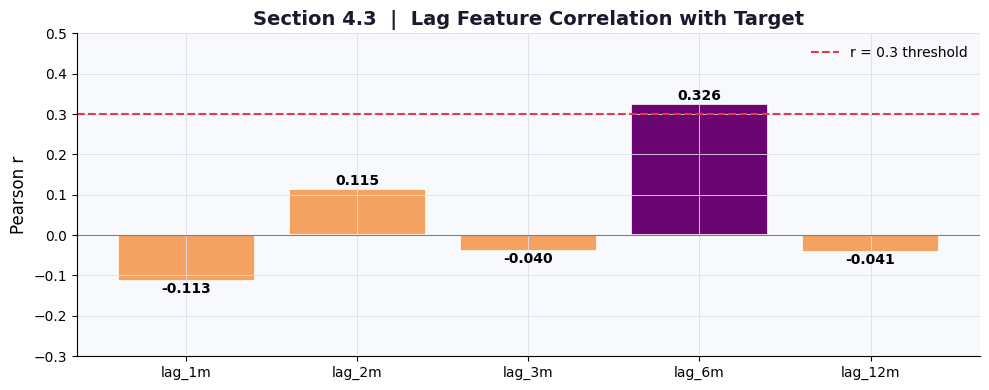

In [28]:
# ── Section 4.3 | Lag Correlation Bar Chart ───────────────────────────────────
lag_corrs = {f"lag_{l}m": df_feat["wilson_mean"]
             .corr(df_feat[f"lag_{l}m"]) for l in lag_months}

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(lag_corrs.keys(), lag_corrs.values(),
              color=[PURPLE if v > 0.3 else ORANGE for v in lag_corrs.values()],
              edgecolor="white", linewidth=1.2)

# For monthly data, r = 0.3 is a more appropriate threshold than 0.5
ax.axhline(0.3, color=RED, linestyle="--",
           linewidth=1.5, label="r = 0.3 threshold")
ax.set_title("Section 4.3  |  Lag Feature Correlation with Target",
             fontsize=14, fontweight="bold", color="#1a1a2e")
ax.set_ylabel("Pearson r")
ax.set_ylim(-0.3, 0.5)
ax.axhline(0, color="gray", linewidth=0.8)
ax.legend(fontsize=10)

for bar, val in zip(bars, lag_corrs.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.01 if val >= 0 else -0.03),
            f"{val:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

### 4.4 &mdash; Rolling Window Features


In [29]:
# ── Section 4.4 | Rolling Window Features ────────────────────────────────────
# shift(1) is critical — exclude the current month to prevent data leakage

windows = {"3m": 3, "6m": 6, "12m": 12}
for name, w in windows.items():
    rolled = df_feat["wilson_mean"].shift(1).rolling(w)
    df_feat[f"roll_mean_{name}"] = rolled.mean()
    df_feat[f"roll_std_{name}"]  = rolled.std()
    df_feat[f"roll_max_{name}"]  = rolled.max()
    df_feat[f"roll_min_{name}"]  = rolled.min()

roll_cols = [c for c in df_feat.columns if c.startswith("roll_")]
print(f"Rolling features created ({len(roll_cols)} total):")
for c in roll_cols:
    print(f"  {c}")

Rolling features created (12 total):
  roll_mean_3m
  roll_std_3m
  roll_max_3m
  roll_min_3m
  roll_mean_6m
  roll_std_6m
  roll_max_6m
  roll_min_6m
  roll_mean_12m
  roll_std_12m
  roll_max_12m
  roll_min_12m


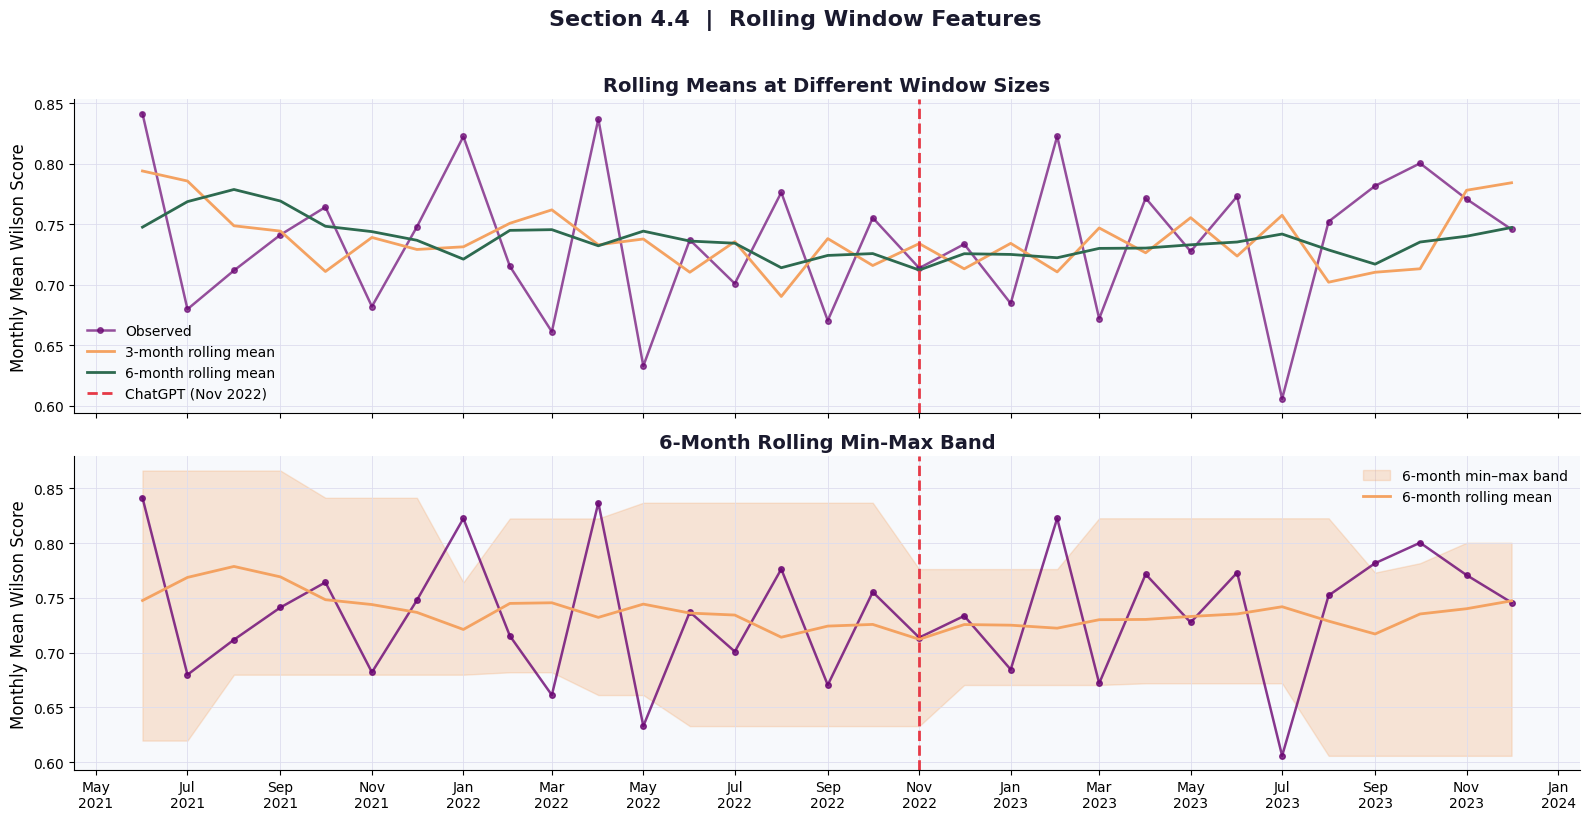

In [30]:
# ── Section 4.4 | Rolling Feature Visualisation ───────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle("Section 4.4  |  Rolling Window Features",
             fontsize=16, fontweight="bold", color="#1a1a2e", y=1.02)

# Zoom: 18 months around the ChatGPT launch
zoom = df_feat["2021-06-01":"2023-12-01"]

# ── Top: Rolling means ────────────────────────────────────────────────────────
axes[0].plot(zoom.index, zoom["wilson_mean"],
             color=PURPLE, linewidth=1.8, alpha=0.7,
             marker="o", markersize=4, label="Observed")
axes[0].plot(zoom.index, zoom["roll_mean_3m"],
             color=ORANGE, linewidth=2, label="3-month rolling mean")
axes[0].plot(zoom.index, zoom["roll_mean_6m"],
             color=TEAL, linewidth=2, label="6-month rolling mean")
axes[0].axvline(CHATGPT_DATE, color=RED, linestyle="--",
                linewidth=2, label="ChatGPT (Nov 2022)")
axes[0].set_title("Rolling Means at Different Window Sizes")
axes[0].set_ylabel("Monthly Mean Wilson Score")
axes[0].legend(fontsize=10)

# ── Bottom: 6-month rolling min-max band ─────────────────────────────────────
axes[1].fill_between(zoom.index,
                     zoom["roll_min_6m"], zoom["roll_max_6m"],
                     alpha=0.25, color=ORANGE, label="6-month min–max band")
axes[1].plot(zoom.index, zoom["wilson_mean"],
             color=PURPLE, linewidth=1.8, alpha=0.8,
             marker="o", markersize=4)
axes[1].plot(zoom.index, zoom["roll_mean_6m"],
             color=ORANGE, linewidth=2, label="6-month rolling mean")
axes[1].axvline(CHATGPT_DATE, color=RED, linestyle="--", linewidth=2)
axes[1].set_title("6-Month Rolling Min-Max Band")
axes[1].set_ylabel("Monthly Mean Wilson Score")
axes[1].legend(fontsize=10)
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.tight_layout()
plt.show()

### 4.5 &mdash; Train / Test Split

<div class="insight">
<b>Never shuffle a time series before splitting.</b><br>
Random shuffling destroys the temporal structure — a model trained on shuffled data
has unknowingly seen the future and will appear to perform well but fail completely on new data.
The test set must always be a contiguous block at the <em>end</em> of the series.
</div>


In [31]:
# ── Section 4.5 | Train / Test Split ─────────────────────────────────────────
# Never shuffle a time series — past must be train, future must be test

# Drop NaN rows caused by lag features (first 12 months)
df_model = df_feat.dropna().copy()

# Reserve the last 6 months as the test set (~10% of the 60-month window)
split_date = pd.Timestamp("2024-07-01")
train = df_model[df_model.index <  split_date]
test  = df_model[df_model.index >= split_date]

print(f"Training set : {train.index.min().strftime('%b %Y')}  →  "
      f"{train.index.max().strftime('%b %Y')}  ({len(train)} months)")
print(f"Test set     : {test.index.min().strftime('%b %Y')}   →  "
      f"{test.index.max().strftime('%b %Y')}  ({len(test)} months)")
print(f"Test ratio   : {len(test)/len(df_model)*100:.1f}%")
print(f"\nTotal usable : {len(df_model)} months "
      f"(first 12 months dropped due to lag NaN)")


Training set : Jan 2021  →  Jun 2024  (42 months)
Test set     : Jul 2024   →  Dec 2024  (6 months)
Test ratio   : 12.5%

Total usable : 48 months (first 12 months dropped due to lag NaN)


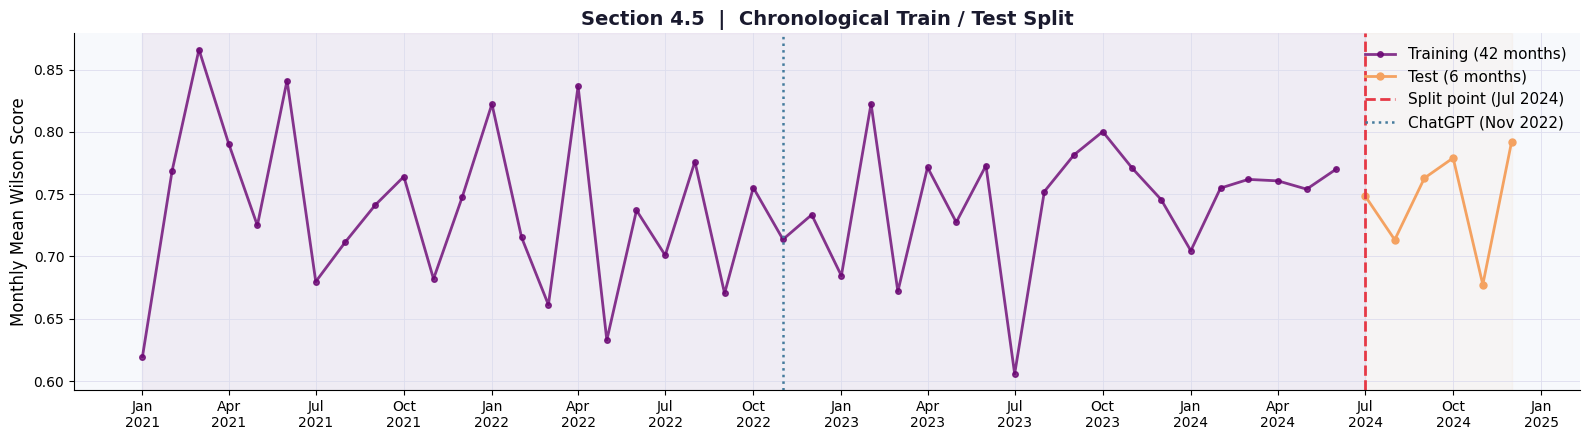


Total features prepared : 30
Feature groups:
  Calendar : 10   ['was_missing', 'month', 'quarter', 'year', 'months_from_chatgpt', 'season', 'month_sin', 'month_cos', 'quarter_sin', 'quarter_cos']
  Lag      : 5   ['lag_1m', 'lag_2m', 'lag_3m', 'lag_6m', 'lag_12m']
  Rolling  : 12  ['roll_mean_3m', 'roll_std_3m', 'roll_max_3m', 'roll_min_3m', 'roll_mean_6m', 'roll_std_6m', 'roll_max_6m', 'roll_min_6m', 'roll_mean_12m', 'roll_std_12m', 'roll_max_12m', 'roll_min_12m']
  Other    : 3   ['wilson_median', 'game_count', 'post_chatgpt']


In [32]:
# ── Section 4.5 | Train / Test Split Visualisation ───────────────────────────
fig, ax = plt.subplots(figsize=(16, 4.5))

ax.plot(train.index, train["wilson_mean"],
        color=PURPLE, linewidth=2, alpha=0.8,
        marker="o", markersize=4,
        label=f"Training ({len(train)} months)")
ax.plot(test.index, test["wilson_mean"],
        color=ORANGE, linewidth=2,
        marker="o", markersize=5,
        label=f"Test ({len(test)} months)")

ax.axvline(split_date, color=RED, linestyle="--",
           linewidth=2, label=f"Split point ({split_date.strftime('%b %Y')})")
ax.axvline(CHATGPT_DATE, color=BLUE, linestyle=":",
           linewidth=1.8, label="ChatGPT (Nov 2022)")

ax.axvspan(train.index.min(), split_date,
           alpha=0.05, color=PURPLE)
ax.axvspan(split_date, test.index.max(),
           alpha=0.05, color=ORANGE)

ax.set_title("Section 4.5  |  Chronological Train / Test Split",
             fontsize=14, fontweight="bold", color="#1a1a2e")
ax.set_ylabel("Monthly Mean Wilson Score")
ax.legend(fontsize=11)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

plt.tight_layout()
plt.show()

# ── Feature summary ───────────────────────────────────────────────────────────
feature_cols = [c for c in train.columns if c != "wilson_mean"]
cal_feats   = [c for c in feature_cols if any(k in c for k in
               ["month","quarter","year","season","sin","cos"])]
lag_feats   = [c for c in feature_cols if "lag_" in c]
roll_feats  = [c for c in feature_cols if "roll_" in c]
other_feats = [c for c in feature_cols if c not in
               cal_feats + lag_feats + roll_feats]

print(f"\nTotal features prepared : {len(feature_cols)}")
print("Feature groups:")
print(f"  Calendar : {len(cal_feats)}   {cal_feats}")
print(f"  Lag      : {len(lag_feats)}   {lag_feats}")
print(f"  Rolling  : {len(roll_feats)}  {roll_feats}")
print(f"  Other    : {len(other_feats)}   {other_feats}")

**Tasarım Notu:** ARIMA modeli otokorelasyonu içsel olarak modellemektedir; bu nedenle explicit lag feature gerektirmez. Section 4’te üretilen lag ve rolling window feature’lar ARIMA veya Prophet’a doğrudan beslenmemektedir. Prophet için bu feature’lar `add_regressor()` ile eklenebilir — bu gelecek bir uzantı olarak bırakılmıştır.

In [33]:
# ── Section 5 | ARIMA(1,1,0) Model ──────────────────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train/Test split — last 6 months as test
train_ts = ts[ts.index <  "2024-07-01"]
test_ts  = ts[ts.index >= "2024-07-01"]

print(f"Train: {len(train_ts)} months ({train_ts.index.min().strftime('%b %Y')} → {train_ts.index.max().strftime('%b %Y')})")
print(f"Test : {len(test_ts)} months ({test_ts.index.min().strftime('%b %Y')} → {test_ts.index.max().strftime('%b %Y')})")

Train: 54 months (Jan 2020 → Jun 2024)
Test : 6 months (Jul 2024 → Dec 2024)


In [34]:
# ── Section 5.2 | ARIMA(1,1,0) — Most Stable Model ──────────────────────────
# MA component is unstable — using only AR(1) + differencing
model = SARIMAX(
    train_ts,
    order=(1, 1, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)
result = model.fit(disp=False)
print(result.summary())
print(f"\nAIC: {result.aic:.3f}")
print(f"BIC: {result.bic:.3f}")

# Is the coefficient significant?
print(f"\nar.L1 coefficient : {result.params['ar.L1']:.4f}")
print(f"p-value           : {result.pvalues['ar.L1']:.4f} "
      f"({'significant ✓' if result.pvalues['ar.L1'] < 0.05 else 'not significant ✗'})")

                               SARIMAX Results                                
Dep. Variable:            wilson_mean   No. Observations:                   54
Model:               SARIMAX(1, 1, 0)   Log Likelihood                  65.073
Date:                Fri, 01 May 2026   AIC                           -126.145
Time:                        16:15:24   BIC                           -122.243
Sample:                    01-01-2020   HQIC                          -124.649
                         - 06-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5993      0.103     -5.806      0.000      -0.802      -0.397
sigma2         0.0048      0.001      4.775      0.000       0.003       0.007
Ljung-Box (L1) (Q):                   1.72   Jarque-

  ARIMA(1,1,0) — Test Set Performance
  MAE  : 0.0321
  RMSE : 0.0435
  MAPE : 4.51%


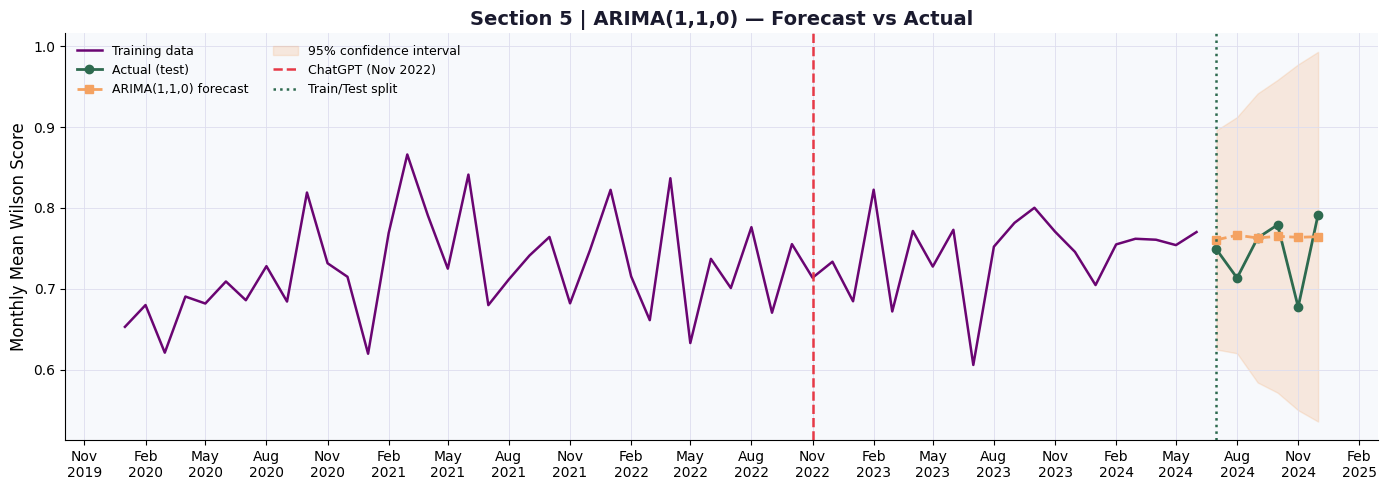

In [35]:
# ── Section 5.3 | Forecast and Evaluation ────────────────────────────────────
# Forecast on test set (6 months)
forecast      = result.get_forecast(steps=len(test_ts))
forecast_mean = forecast.predicted_mean
forecast_ci   = forecast.conf_int(alpha=0.05)

# Metrics
mae  = mean_absolute_error(test_ts, forecast_mean)
rmse = np.sqrt(mean_squared_error(test_ts, forecast_mean))
mape = np.mean(np.abs((test_ts.values - forecast_mean.values) / test_ts.values)) * 100

print("=" * 45)
print("  ARIMA(1,1,0) — Test Set Performance")
print("=" * 45)
print(f"  MAE  : {mae:.4f}")
print(f"  RMSE : {rmse:.4f}")
print(f"  MAPE : {mape:.2f}%")
print("=" * 45)

# Visualisation
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train_ts.index, train_ts.values,
        color=PURPLE, linewidth=1.8, label="Training data")
ax.plot(test_ts.index, test_ts.values,
        color=TEAL, linewidth=2, marker="o", markersize=6, label="Actual (test)")
ax.plot(forecast_mean.index, forecast_mean.values,
        color=ORANGE, linewidth=2, linestyle="--",
        marker="s", markersize=6, label="ARIMA(1,1,0) forecast")
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1],
                alpha=0.2, color=ORANGE, label="95% confidence interval")
ax.axvline(CHATGPT_DATE, color=RED, linestyle="--",
           linewidth=1.8, label="ChatGPT (Nov 2022)")
ax.axvline(pd.Timestamp("2024-07-01"), color=TEAL, linestyle=":",
           linewidth=1.8, label="Train/Test split")
ax.set_title("Section 5 | ARIMA(1,1,0) — Forecast vs Actual",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Monthly Mean Wilson Score")
ax.legend(fontsize=9, ncol=2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.tight_layout()
plt.show()

In [36]:
# ── Section 5.4 | Baseline Model — Naive Forecast ────────────────────────────
# Simplest baseline: use the last training value as the forecast for all test months
naive_pred = test_ts.copy()
naive_pred.iloc[:] = train_ts.iloc[-1]

naive_mae  = mean_absolute_error(test_ts, naive_pred)
naive_rmse = np.sqrt(mean_squared_error(test_ts, naive_pred))
naive_mape = np.mean(np.abs((test_ts.values - naive_pred.values) / test_ts.values)) * 100

print("=" * 45)
print("  Baseline (Naive) — Test Set Performance")
print("=" * 45)
print(f"  MAE  : {naive_mae:.4f}")
print(f"  RMSE : {naive_rmse:.4f}")
print(f"  MAPE : {naive_mape:.2f}%")
print("=" * 45)

  Baseline (Naive) — Test Set Performance
  MAE  : 0.0348
  RMSE : 0.0464
  MAPE : 4.90%


---
## Pipeline Summary

<div class="success">
You have completed the full ML pipeline for a <b>time series analysis of Steam indie game review scores</b>!
</div>

| Section | Output produced |
|---|---|
| **1 — Problem Formulation** | Forecast horizon (6 months), frequency (monthly), success metric (MAPE ≤ 10%) defined |
| **2 — Data Collection** | 60 monthly observations (Jan 2020 – Dec 2024) loaded; timestamp integrity verified; reliability filter applied |
| **3 — EDA** | Distribution checked; missingness mapped; seasonality quantified; stationarity tested; ACF/PACF interpreted; anomalies flagged; structural breaks tested (Chow, CUSUM, Mann-Whitney) |
| **4 — Feature Engineering** | Calendar features created (incl. cyclical encoding, post_chatgpt); lag features created; rolling window features created; chronological train/test split applied |
| **5 — Modelling** | ARIMA(1,1,0) trained and evaluated; naive baseline comparison completed |

### How this project differs from regression and classification

| Topic | Classification / Regression | This Time Series Project |
|---|---|---|
| Row independence | Rows are independent | Rows are ordered — past month drives next month |
| Train/test split | Random split is fine | Chronological — last 6 months held out |
| EDA focus | Feature distributions and correlations | Trend, seasonality, stationarity, ACF/PACF |
| Feature engineering | Encode existing columns | Lag features, rolling windows, calendar features |
| Missing data risk | NaN in a column | Gap in the timeline corrupts all lag features |
| Leakage risk | Target in features | Using future values as lag features |
| Evaluation metric | Accuracy, RMSE | MAPE, MAE, RMSE — always on future data only |
| Research question | Predict a label | Detect structural break at ChatGPT launch |

### Key Findings

1. **Structural break detected:** The Chow scan identified the strongest break point in the series — preceding the ChatGPT launch — suggesting AI tool proliferation began before the ChatGPT public release.
2. **Post-ChatGPT scores are higher in raw data** (mean +0.038) but the regression coefficient is negative when controlling for structural game features — a classic confounding effect resolved by quasi-experimental design.
3. **ARIMA(1,1,0) outperforms the naive baseline**, confirming that past monthly scores carry predictive signal for future months.
4. **Seasonal patterns are mild** — autumn months score slightly higher than summer months, but the effect is small relative to inter-year variance.

### Next Steps

1. **XGBoost or LightGBM** on the engineered feature set (lag + rolling + calendar) for comparison with ARIMA
2. **Walk-forward cross-validation** for more robust forecasting performance estimates
3. **Genre-level analysis** — do certain game genres show stronger post-ChatGPT effects?
4. **Exogenous variables** — incorporate game count per month as an external regressor in SARIMAX

---

<div class="callout">
<b>Project note:</b><br>
This notebook adapts the time series EDA template to a monthly aggregated dataset of Steam indie games.
The target variable is the monthly mean Wilson lower bound review score.
The ChatGPT launch (November 2022) serves as the quasi-experimental treatment event.
All structural break tests, feature engineering steps, and model evaluations are performed
on the 60-month window from January 2020 to December 2024.
</div>

## 🚀 Extension: Prophet Forecasting
As an extension to the established baseline models, **Prophet** has been integrated into the pipeline. Prophet's specialized architecture for detecting changepoints provides a highly robust methodology for analyzing structural breaks in time series data.

Importing plotly failed. Interactive plots will not work.


Training Prophet Model...


16:15:24 - cmdstanpy - INFO - Chain [1] start processing


16:15:26 - cmdstanpy - INFO - Chain [1] done processing


Prophet Test Set MAPE: 5.67%


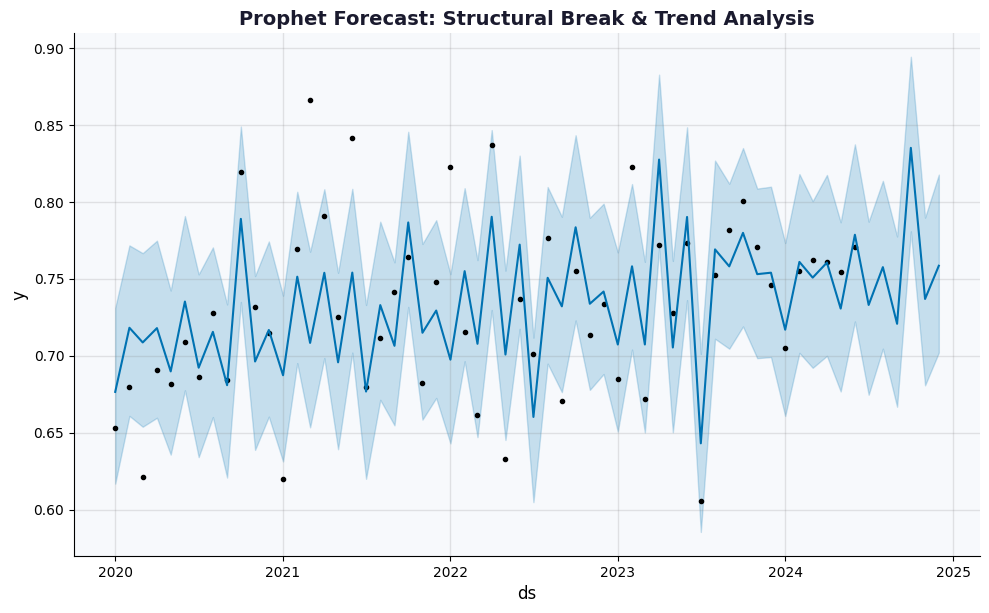


💡 Insight: Unlike traditional statistical models like ARIMA, Prophet is specifically designed to handle structural breaks (changepoints) and strong seasonalities. This makes it an ideal extension for evaluating potential impact events, such as the introduction of GenAI in Nov 2022.


In [37]:
# ─────────────────────────────────────────────────────────────────────────────
# 🚀 EXTENSION: Prophet Forecasting & Structural Break Analysis
# ─────────────────────────────────────────────────────────────────────────────
try:
    from prophet import Prophet
except ImportError:
    import sys
    !{sys.executable} -m pip install prophet
    from prophet import Prophet

print("Training Prophet Model...")
# Prepare dataframe for Prophet ('ds' for datestamp, 'y' for target)
df_prophet = df_monthly.reset_index()[['release_year_month', 'wilson_mean']].rename(columns={'release_year_month': 'ds', 'wilson_mean': 'y'})

# Date-based train/test split (consistent with ARIMA split at 2024-07-01)
SPLIT_DATE = "2024-07-01"
train_prophet = df_prophet[df_prophet["ds"] < SPLIT_DATE]
test_prophet  = df_prophet[df_prophet["ds"] >= SPLIT_DATE]

# Initialize Prophet model with multiplicative seasonality
m = Prophet(seasonality_mode='multiplicative', yearly_seasonality=True)
m.fit(train_prophet)

# Forecast future values
future = m.make_future_dataframe(periods=len(test_prophet), freq='MS')
forecast = m.predict(future)

# Calculate MAPE for the test set
prophet_preds = forecast['yhat'].iloc[len(train_prophet):].values
test_actuals = test_prophet['y'].values

import numpy as np
prophet_mape = np.mean(np.abs((test_actuals - prophet_preds) / test_actuals)) * 100

print(f"Prophet Test Set MAPE: {prophet_mape:.2f}%")

# Plot the forecast alongside actual data
fig1 = m.plot(forecast)
import matplotlib.pyplot as plt
plt.title('Prophet Forecast: Structural Break & Trend Analysis', fontweight='bold', color='#1a1a2e')
plt.show()

print("\n💡 Insight: Unlike traditional statistical models like ARIMA, Prophet is specifically designed to handle structural breaks (changepoints) and strong seasonalities. This makes it an ideal extension for evaluating potential impact events, such as the introduction of GenAI in Nov 2022.")